In [794]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [795]:
import os
import sys
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import matplotlib.patches as patches
import img2pdf

current_dir = Path.cwd()

# Parent directory
parent_dir = current_dir.parent

# Directories containing your modules
vis_dir = parent_dir / "vis"
connected_graphs_dir = parent_dir / "vis_connect"
long_dir = parent_dir / "long_peptide"

# Put them at the front of sys.path
sys.path.insert(0, str(vis_dir))
sys.path.insert(0, str(connected_graphs_dir))
sys.path.insert(0, str(long_dir))

import data_parse
import util
import peptide
import pandas as pd
import numpy as np
import connected_graph
from bisect import bisect_left

In [796]:

path = '/Users/kevinmbp/Desktop/2D_spec_dict/data/virtual_MSMS/VEADIAGHGQEVLIR-mz536-z3_Intensity_Sum'

# 1. Read the spectral file with the custom split to keep annotations intact
with open(path, 'r') as f:
    data = [line.strip().split(None, 3) for line in f if line.strip()]

# 2. Create the spectral DataFrame
df_msms = pd.DataFrame(data, columns=["intensity", "mz", "error", "annotation"])

# 3. Convert columns to numeric types
df_msms["mz"] = pd.to_numeric(df_msms["mz"], errors="coerce")
df_msms["intensity"] = pd.to_numeric(df_msms["intensity"], errors="coerce")
df_msms["error"] = pd.to_numeric(df_msms["error"], errors="coerce")

# 4. Clean up NaNs and sort by m/z (required for merge_asof)
df_msms = df_msms.dropna(subset=["mz", "intensity"]).sort_values("mz").reset_index(drop=True)

# --- Process MMS File ---
mss_input_file = "/Users/kevinmbp/Desktop/2D_spec_dict/data/short_peptide/VEA3+.txt"
mms_df = pd.read_csv(
    mss_input_file,
    sep=r"\s+",
    skiprows=1,
    header=None,
    engine="python"
)

mms_df.columns = ["m/z A", "m/z B", "Covariance", "Partial Cov.", "Score", "Ranking"]
mms_df["m/z A"] = pd.to_numeric(mms_df["m/z A"], errors="coerce")
mms_df["m/z B"] = pd.to_numeric(mms_df["m/z B"], errors="coerce")
tolerance = 0.001

# -------- Match for m/z A --------
a_df = mms_df[["m/z A"]].copy().sort_values("m/z A").reset_index()
a_matched = pd.merge_asof(
    a_df,
    df_msms,
    left_on="m/z A",
    right_on="mz",
    direction="nearest",
    tolerance=tolerance
)
# Rename intensity, annotation, and error for A
a_matched = a_matched.rename(columns={
    "intensity": "intensity A", 
    "annotation": "annotation A",
    "error": "error A"
})
a_matched = a_matched.set_index("index")

# -------- Match for m/z B --------
b_df = mms_df[["m/z B"]].copy().sort_values("m/z B").reset_index()
b_matched = pd.merge_asof(
    b_df,
    df_msms,
    left_on="m/z B",
    right_on="mz",
    direction="nearest",
    tolerance=tolerance
)
# Rename intensity, annotation, and error for B
b_matched = b_matched.rename(columns={
    "intensity": "intensity B", 
    "annotation": "annotation B",
    "error": "error B"
})
b_matched = b_matched.set_index("index")

# -------- Final Join --------
# Add all matched columns back to the original MMS dataframe
mms_df["intensity A"] = a_matched["intensity A"]
mms_df["annotation A"] = a_matched["annotation A"]
mms_df["error A"] = a_matched["error A"]

mms_df["intensity B"] = b_matched["intensity B"]
mms_df["annotation B"] = b_matched["annotation B"]
mms_df["error B"] = b_matched["error B"]

mms_df.head()

,m/z A,m/z B,Covariance,Partial Cov.,Score,Ranking,intensity A,annotation A,error A,intensity B,annotation B,error B
0,156.102426,156.102426,25073159.00,2.503813e+07,1604.311900,-1,968.253174,No Match,-1000.0,968.253174,No Match,-1000.000000
1,156.102426,175.119605,1766662.60,1.577744e+06,183.251870,282,968.253174,No Match,-1000.0,8633.249023,y1 (+1),-0.000653
2,156.102426,183.113388,1159704.90,9.680421e+05,139.187240,740,968.253174,No Match,-1000.0,6728.792969,b2-H2O-CO (+1) / b2-HCOOH (+1) / internal 4:5-...,-0.000584
3,156.102426,187.072039,116453.27,9.340415e+04,28.558445,4715,968.253174,No Match,-1000.0,973.557800,internal 3:4 (+1),-0.000706
4,156.102426,195.088350,-310522.16,-3.434978e+05,-186.746850,13511,968.253174,No Match,-1000.0,1063.230103,internal 7:8 (+1) / internal 8:9 (+1),-0.000698


In [797]:
mms_df[mms_df['Ranking'] == 46]

,m/z A,m/z B,Covariance,Partial Cov.,Score,Ranking,intensity A,annotation A,error A,intensity B,annotation B,error B
8518,500.237156,1008.563901,7213199.7,6870218.2,414.41006,46,1889.202759,internal 2:6 (+1),-0.002052,9142.976563,y9 (+1),-0.005397
28932,1008.563901,500.237156,7213199.7,6870218.2,414.41006,46,9142.976563,y9 (+1),-0.005397,1889.202759,internal 2:6 (+1),-0.002052


In [798]:
mms_df[mms_df['Ranking'] == 23]

,m/z A,m/z B,Covariance,Partial Cov.,Score,Ranking,intensity A,annotation A,error A,intensity B,annotation B,error B
23824,694.319024,814.482029,14738272.0,14129983.0,603.27517,23,1683.645386,internal 2:8 (+1),-0.003544,21098.802734,y7 (+1),-0.003901
27976,814.482029,694.319024,14738272.0,14129983.0,603.27517,23,21098.802734,y7 (+1),-0.003901,1683.645386,internal 2:8 (+1),-0.003544


In [799]:
mms_df[mms_df['Ranking'] == 29]

,m/z A,m/z B,Covariance,Partial Cov.,Score,Ranking,intensity A,annotation A,error A,intensity B,annotation B,error B
4695,401.288604,1107.512648,6112000.6,5922276.2,535.28676,29,7515.183105,y3 (+1),-0.001524,1140.277710,b11 (+1) / internal 2:12 (+1),-0.006120
29780,1107.512648,401.288604,6112000.6,5922276.2,535.28676,29,1140.277710,b11 (+1) / internal 2:12 (+1),-0.006120,7515.183105,y3 (+1),-0.001524


In [800]:
mms_df = mms_df[['m/z A', 'm/z B', 'Ranking', 'annotation A', 'annotation B']]
mms_df = mms_df[mms_df['Ranking'] != -1]
mms_df = mms_df[mms_df['Ranking'] <= 50]

In [801]:
target_rankings = [11, 5, 37, 11]

rows_ordered = pd.concat(
    [mms_df[mms_df["Ranking"] == r] for r in target_rankings],
    ignore_index=False
)

rows_ordered

,m/z A,m/z B,Ranking,annotation A,annotation B
17034,622.296933,757.460091,11,internal 3:9 (+1) / b7-H2O-NH3 (+1) (C13),y6 (+1)
27241,757.460091,622.296933,11,y6 (+1),internal 3:9 (+1) / b7-H2O-NH3 (+1) (C13)
17377,629.400750,750.356517,5,y5 (+1),internal 3:10 (+1)
26373,750.356517,629.400750,5,internal 3:10 (+1),y5 (+1)
17035,622.296933,758.462697,37,internal 3:9 (+1) / b7-H2O-NH3 (+1) (C13),y6 (+1) (C13)
27415,758.462697,622.296933,37,y6 (+1) (C13),internal 3:9 (+1) / b7-H2O-NH3 (+1) (C13)
17034,622.296933,757.460091,11,internal 3:9 (+1) / b7-H2O-NH3 (+1) (C13),y6 (+1)
27241,757.460091,622.296933,11,y6 (+1),internal 3:9 (+1) / b7-H2O-NH3 (+1) (C13)


In [802]:
def plot_ffc_map(
    df,
    mz_a_col="mz_A",
    mz_b_col="mz_B",
    ranking_col="ranking",
    lines=None,
    num_random_lines=4,
    xlim=None,
    ylim=None,
    figsize=(8, 7),
    point_size=80,
    line_alpha=0.45,
    random_seed=42
):
    """
    Plot an FFC map using mz_A, mz_B, and FFC ranking.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataframe containing mz_A, mz_B, and ranking columns.

    mz_a_col : str
        Column name for mz_A values.

    mz_b_col : str
        Column name for mz_B values.

    ranking_col : str
        Column name for FFC ranking.

    lines : list of dict, optional
        List of line parameters. Each line should be a dictionary like:
            {"slope": -1, "intercept": 1400, "color": "blue", "label": "line 1"}

        The line is drawn as:
            y = slope * x + intercept

        If None, random lines will be generated.

    num_random_lines : int
        Number of random lines to draw if lines is None.

    xlim : tuple, optional
        x-axis limits, for example (150, 1250).

    ylim : tuple, optional
        y-axis limits, for example (150, 1250).

    figsize : tuple
        Figure size.

    point_size : int
        Scatter point size.

    line_alpha : float
        Transparency of the lines.

    random_seed : int
        Random seed for generating random lines.
    """

    # Make a copy to avoid modifying the original dataframe
    data = df.copy()

    # Convert columns to numeric values
    data[mz_a_col] = pd.to_numeric(data[mz_a_col], errors="coerce")
    data[mz_b_col] = pd.to_numeric(data[mz_b_col], errors="coerce")
    data[ranking_col] = pd.to_numeric(data[ranking_col], errors="coerce")

    # Remove rows with missing values
    data = data.dropna(subset=[mz_a_col, mz_b_col, ranking_col])

    # Determine plot ranges
    if xlim is None:
        x_min = data[mz_a_col].min() - 50
        x_max = data[mz_a_col].max() + 200
        xlim = (x_min, x_max)

    if ylim is None:
        y_min = data[mz_b_col].min() - 50
        y_max = data[mz_b_col].max() + 200
        ylim = (y_min, y_max)

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Scatter plot
    scatter = ax.scatter(
        data[mz_a_col],
        data[mz_b_col],
        c=data[ranking_col],
        cmap="plasma",
        s=point_size,
        edgecolors="cyan",
        linewidths=1.5,
        alpha=0.75
    )

    # Color bar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("FFC ranking", fontsize=14)

    # Generate random lines if no line parameters are provided
    if lines is None:
        np.random.seed(random_seed)
        lines = []

        for i in range(num_random_lines):
            slope = np.random.uniform(-2.0, -0.3)
            intercept = np.random.uniform(800, 1700)
            color = np.random.choice(["blue", "green", "purple", "orange", "red"])

            lines.append({
                "slope": slope,
                "intercept": intercept,
                "color": color,
                "label": f"random line {i + 1}"
            })

    # Draw lines
    x_values = np.linspace(xlim[0], xlim[1], 500)

    for line in lines:
        slope = line.get("slope")
        intercept = line.get("intercept")
        color = line.get("color", "black")
        label = line.get("label", None)

        y_values = slope * x_values + intercept

        ax.plot(
            x_values,
            y_values,
            color=color,
            alpha=line_alpha,
            linewidth=2,
            label=label
        )

    # Labels and formatting
    ax.set_xlabel("m/z A", fontsize=14)
    ax.set_ylabel("m/z B", fontsize=14)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.tick_params(axis="both", labelsize=12)

    # Optional legend, useful when you start labeling exact lines
    if any(line.get("label") is not None for line in lines):
        ax.legend()

    plt.tight_layout()
    plt.show()

    return fig, ax

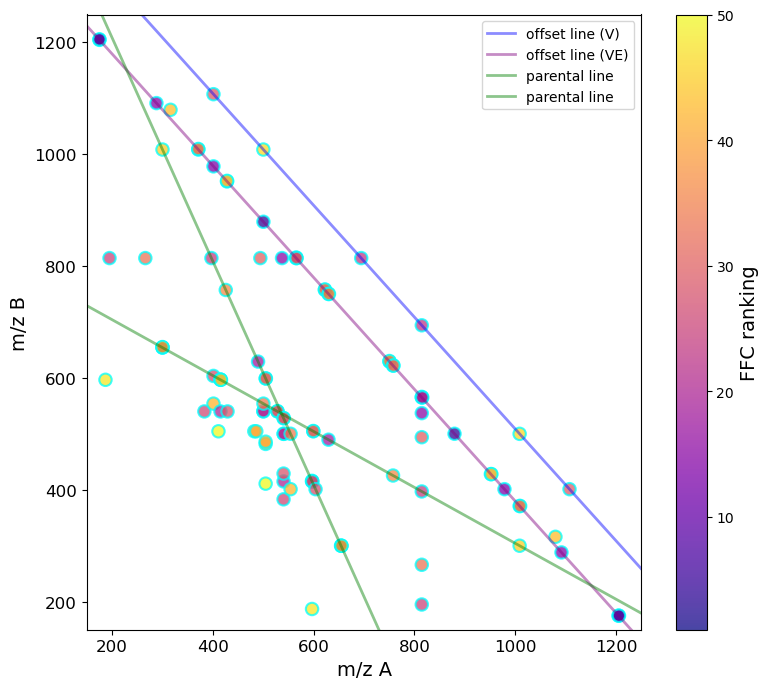

(<Figure size 800x700 with 2 Axes>, <Axes: xlabel='m/z A', ylabel='m/z B'>)

In [803]:
exact_lines = [
    {"slope": -1, "intercept": 1608.869-100.069, "color": "blue", "label": "offset line (V)"},
    {"slope": -1, "intercept": 1608.869 - 229.112, "color": "purple", "label": "offset line (VE)"},
    {"slope": -0.5, "intercept": 1608.869/2, "color": "green", "label": "parental line"},
    {"slope": -2, "intercept": 1608.869, "color": "green", "label": "parental line"}
]

plot_ffc_map(
    mms_df,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    ranking_col="Ranking",
    lines=exact_lines,
    xlim=(150, 1250),
    ylim=(150, 1250)
)

In [804]:
PEP_SEQ = "VEADIAGHGQEVLIR"
CHARGE = 3
pep = peptide.Pep(f"[{PEP_SEQ}+{CHARGE}H]{CHARGE}+", end_h20=True)

In [805]:
b_ions = {f'b{i}':pep.ion_mass(f'b{i}') for i in range(1, len(PEP_SEQ))}
y_ions = {f'y{i}':pep.ion_mass(f'y{i}') for i in range(1, len(PEP_SEQ))}

In [806]:
def plot_ffc_map(
    df,
    mz_a_col="mz_A",
    mz_b_col="mz_B",
    ranking_col="ranking",
    lines=None,
    b_ions=None,
    y_ions=None,
    num_random_lines=4,
    xlim=None,
    ylim=None,
    figsize=(8, 7),
    point_size=80,
    line_alpha=0.45,
    grid_alpha=0.12,
    grid_linewidth=0.8,
    random_seed=42
):
    """
    Plot an FFC map using mz_A, mz_B, and FFC ranking.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataframe containing mz_A, mz_B, and ranking columns.

    b_ions : dict, optional
        Dictionary of b-ion values, for example:
            {"b1": 175.119, "b2": 304.162, "b3": 419.189}

        These values are drawn as vertical gray grid lines.

    y_ions : dict, optional
        Dictionary of y-ion values, for example:
            {"y1": 175.119, "y2": 288.203, "y3": 417.246}

        These values are drawn as horizontal gray grid lines.

    lines : list of dict, optional
        Main line parameters. Each line should be:
            {"slope": -1, "intercept": 1400, "color": "blue", "label": "parental line"}

        The line is drawn as:
            y = slope * x + intercept
    """

    data = df.copy()

    data[mz_a_col] = pd.to_numeric(data[mz_a_col], errors="coerce")
    data[mz_b_col] = pd.to_numeric(data[mz_b_col], errors="coerce")
    data[ranking_col] = pd.to_numeric(data[ranking_col], errors="coerce")

    data = data.dropna(subset=[mz_a_col, mz_b_col, ranking_col])

    if xlim is None:
        x_min = data[mz_a_col].min() - 50
        x_max = data[mz_a_col].max() + 200
        xlim = (x_min, x_max)

    if ylim is None:
        y_min = data[mz_b_col].min() - 50
        y_max = data[mz_b_col].max() + 200
        
        ylim = (y_min, y_max)

    fig, ax = plt.subplots(figsize=figsize)

    # Add barely visible b/y ion grid first, so it stays behind the points
    if b_ions is not None:
        for ion_name, mz_value in b_ions.items():
            mz_value = float(mz_value)
            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(
                    x=mz_value,
                    color="gray",
                    alpha=grid_alpha,
                    linewidth=grid_linewidth,
                    zorder=0
                )

    if y_ions is not None:
        for ion_name, mz_value in y_ions.items():
            mz_value = float(mz_value)
            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(
                    y=mz_value,
                    color="gray",
                    alpha=grid_alpha,
                    linewidth=grid_linewidth,
                    zorder=0
                )

    # Scatter plot
    scatter = ax.scatter(
        data[mz_a_col],
        data[mz_b_col],
        c=data[ranking_col],
        cmap="plasma",
        s=point_size,
        edgecolors="cyan",
        linewidths=1.5,
        alpha=0.75,
        zorder=3
    )

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("FFC ranking", fontsize=14)

    # Generate random lines if no exact lines are provided
    if lines is None:
        np.random.seed(random_seed)
        lines = []

        for i in range(num_random_lines):
            slope = np.random.uniform(-2.0, -0.3)
            intercept = np.random.uniform(800, 1700)
            color = np.random.choice(["blue", "green", "purple", "orange", "red"])

            lines.append({
                "slope": slope,
                "intercept": intercept,
                "color": color,
                "label": f"random line {i + 1}"
            })

    # Draw main diagonal/charge lines
    x_values = np.linspace(xlim[0], xlim[1], 500)

    for line in lines:
        slope = line.get("slope")
        intercept = line.get("intercept")
        color = line.get("color", "black")
        label = line.get("label", None)

        y_values = slope * x_values + intercept

        ax.plot(
            x_values,
            y_values,
            color=color,
            alpha=line_alpha,
            linewidth=2,
            label=label,
            zorder=2
        )

    ax.set_xlabel("m/z A", fontsize=14)
    ax.set_ylabel("m/z B", fontsize=14)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.tick_params(axis="both", labelsize=12)

    if any(line.get("label") is not None for line in lines):
        ax.legend()

    plt.tight_layout()
    plt.show()

    return fig, ax

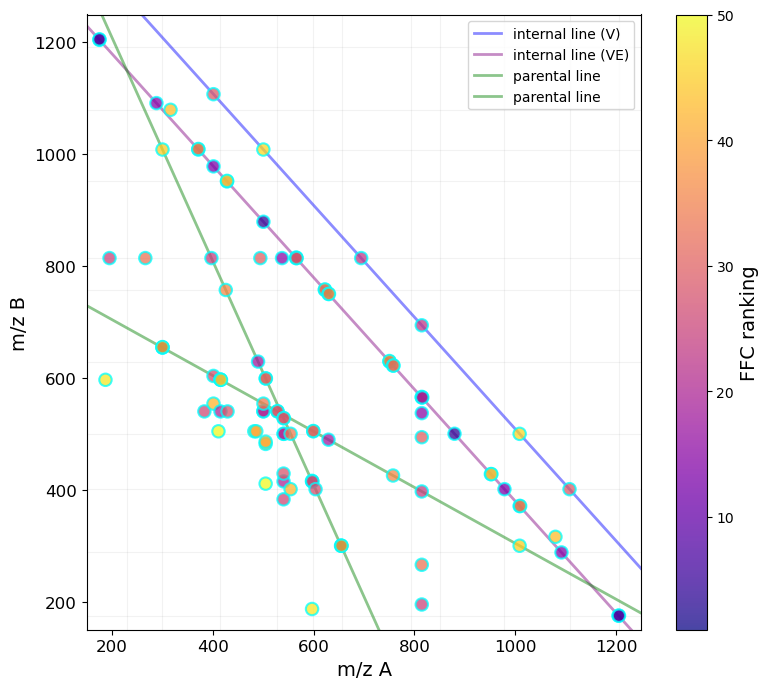

(<Figure size 800x700 with 2 Axes>, <Axes: xlabel='m/z A', ylabel='m/z B'>)

In [807]:
exact_lines = [
    {"slope": -1, "intercept": 1608.869-100.069, "color": "blue", "label": "internal line (V)"},
    {"slope": -1, "intercept": 1608.869 - 229.112, "color": "purple", "label": "internal line (VE)"},
    {"slope": -0.5, "intercept": 1608.869/2, "color": "green", "label": "parental line"},
    {"slope": -2, "intercept": 1608.869, "color": "green", "label": "parental line"}
]

plot_ffc_map(
    mms_df,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    ranking_col="Ranking",
    b_ions=b_ions,
    y_ions=y_ions,
    xlim=(150, 1250),
    ylim=(150, 1250),
    grid_alpha=0.10,
    lines=exact_lines
)

In [808]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_ffc_map(
    df,
    mz_a_col="mz_A",
    mz_b_col="mz_B",
    ranking_col="ranking",
    lines=None,
    b_ions=None,
    y_ions=None,
    xlim=None,
    ylim=None,
    start_from_zero=True,
    figsize=(8, 7),
    point_size=80,
    line_alpha=0.45,
    grid_alpha=0.12,
    grid_linewidth=0.8,
    grid_label_alpha=0.45,
    grid_label_fontsize=7,
    show_grid_labels=True
):
    """
    Plot an FFC map using mz_A, mz_B, and FFC ranking.

    If lines=None, no diagonal/charge lines will be drawn.
    """

    data = df.copy()

    # Convert columns to numeric values
    data[mz_a_col] = pd.to_numeric(data[mz_a_col], errors="coerce")
    data[mz_b_col] = pd.to_numeric(data[mz_b_col], errors="coerce")
    data[ranking_col] = pd.to_numeric(data[ranking_col], errors="coerce")

    # Remove invalid rows
    data = data.dropna(subset=[mz_a_col, mz_b_col, ranking_col])

    if data.empty:
        raise ValueError("No valid data points remain after cleaning the dataframe.")

    # Determine plot ranges
    if xlim is None:
        if start_from_zero:
            xlim = (0, data[mz_a_col].max() + 50)
        else:
            xlim = (data[mz_a_col].min() - 50, data[mz_a_col].max() + 50)

    if ylim is None:
        if start_from_zero:
            ylim = (0, data[mz_b_col].max() + 50)
        else:
            ylim = (data[mz_b_col].min() - 50, data[mz_b_col].max() + 50)

    fig, ax = plt.subplots(figsize=figsize)

    # ------------------------------------------------------------
    # Add faint b/y ion grid
    # ------------------------------------------------------------

    b_label_y = ylim[0] + 0.02 * (ylim[1] - ylim[0])
    y_label_x = xlim[0] + 0.01 * (xlim[1] - xlim[0])

    if b_ions is not None:
        for ion_name, mz_value in b_ions.items():
            mz_value = float(mz_value)

            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(
                    x=mz_value,
                    color="gray",
                    alpha=grid_alpha,
                    linewidth=grid_linewidth,
                    zorder=0
                )

                if show_grid_labels:
                    ax.text(
                        mz_value,
                        b_label_y,
                        ion_name,
                        color="gray",
                        alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        rotation=90,
                        ha="center",
                        va="bottom",
                        zorder=1
                    )

    if y_ions is not None:
        for ion_name, mz_value in y_ions.items():
            mz_value = float(mz_value)

            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(
                    y=mz_value,
                    color="gray",
                    alpha=grid_alpha,
                    linewidth=grid_linewidth,
                    zorder=0
                )

                if show_grid_labels:
                    ax.text(
                        y_label_x,
                        mz_value,
                        ion_name,
                        color="gray",
                        alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        ha="left",
                        va="center",
                        zorder=1
                    )

    # ------------------------------------------------------------
    # Scatter plot
    # ------------------------------------------------------------

    scatter = ax.scatter(
        data[mz_a_col],
        data[mz_b_col],
        c=data[ranking_col],
        cmap="plasma",
        s=point_size,
        edgecolors="cyan",
        linewidths=1.5,
        alpha=0.75,
        zorder=3
    )

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("FFC ranking", fontsize=14)

    # ------------------------------------------------------------
    # Draw main diagonal/charge lines only if provided
    # ------------------------------------------------------------

    if lines is not None:
        x_values = np.linspace(xlim[0], xlim[1], 500)

        for line in lines:
            slope = line.get("slope")
            intercept = line.get("intercept")
            color = line.get("color", "black")
            label = line.get("label", None)

            y_values = slope * x_values + intercept

            ax.plot(
                x_values,
                y_values,
                color=color,
                alpha=line_alpha,
                linewidth=2,
                label=label,
                zorder=2
            )

        if any(line.get("label") is not None for line in lines):
            ax.legend()

    # ------------------------------------------------------------
    # Axis labels and formatting
    # ------------------------------------------------------------

    ax.set_xlabel("m/z A", fontsize=14)
    ax.set_ylabel("m/z B", fontsize=14)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.tick_params(axis="both", labelsize=12)

    plt.tight_layout()
    plt.show()

    return fig, ax

    ax.tick_params(axis="both", labelsize=12)

    if lines is not None and any(line.get("label") is not None for line in lines):
        ax.legend()

    plt.tight_layout()
    plt.show()

    return fig, ax

In [809]:
combined_ions = {**y_ions, **b_ions}

In [810]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from adjustText import adjust_text
except Exception:  # adjustText optional
    adjust_text = None


def _arrange_labels(texts, xs, ys, ax):
    """Run adjustText with version-tolerant kwargs (falls back gracefully)."""
    if adjust_text is None or not texts:
        return
    arrow = dict(arrowstyle="-", color="#9aa3ad", lw=0.5)
    try:  # newer adjustText API
        adjust_text(texts, x=xs, y=ys, ax=ax, arrowprops=arrow,
                    expand=(1.25, 1.4), force_text=(0.4, 0.5), max_move=None)
    except TypeError:
        try:  # older API
            adjust_text(texts, x=xs, y=ys, ax=ax, arrowprops=arrow,
                        expand=(1.3, 1.5), force_points=(0.3, 0.3),
                        force_text=(0.5, 0.5), iter_lim=300)
        except TypeError:
            adjust_text(texts, x=xs, y=ys, ax=ax, arrowprops=arrow)


def plot_ffc_map(
    df,
    mz_a_col="mz_A",
    mz_b_col="mz_B",
    ranking_col="ranking",
    lines=None,
    b_ions=None,
    y_ions=None,
    xlim=None,
    ylim=None,
    start_from_zero=True,
    figsize=(8.5, 7.5),
    point_size=80,
    cmap="plasma",
    point_alpha=0.85,             # crisp points (was 0.75)
    point_edgecolor="white",      # white halo separates overlapping points (was "cyan")
    point_linewidth=0.5,          # thinner edge (was 1.5)
    line_alpha=0.55,
    b_ion_color="#2f6690",        # b-ions: muted blue
    y_ion_color="#c0504d",        # y-ions: muted brick-red
    grid_alpha=0.30,              # solid (primary-axis) ladder lines
    dashed_grid_alpha=0.22,       # dashed (complementary-axis) ladder lines
    grid_linewidth=0.8,
    grid_label_alpha=0.75,
    grid_label_fontsize=7,
    show_grid_labels=True,
    annotate_ranking=False,       # off: this version doesn't label individual points
    annotation_fontsize=7,
    spine_color="#cfd4d9",
    tick_color="#5a5f66",
    equal_aspect=True,            # force a square plotting box
    save_path=None,               # set a path to also save the figure
):
    """
    Plot an FFC map using mz_A, mz_B, and FFC ranking.

    Ion grid (b = blue, y = red), four sides:
      - b-ions: solid vertical   (labels bottom) + dashed horizontal (labels right)
      - y-ions: solid horizontal  (labels left)  + dashed vertical   (labels top)

    Points are coloured by ``ranking_col`` and labelled with their ranking
    (de-overlapped with adjustText). If ``lines=None`` no diagonals are drawn.
    """
    data = df.copy()

    data[mz_a_col] = pd.to_numeric(data[mz_a_col], errors="coerce")
    data[mz_b_col] = pd.to_numeric(data[mz_b_col], errors="coerce")
    data[ranking_col] = pd.to_numeric(data[ranking_col], errors="coerce")

    data = data.dropna(subset=[mz_a_col, mz_b_col, ranking_col])
    if data.empty:
        raise ValueError("No valid data points remain after cleaning the dataframe.")

    # Determine plot ranges (remember whether the user supplied them)
    xlim_auto = xlim is None
    ylim_auto = ylim is None
    if xlim_auto:
        xlim = (0, data[mz_a_col].max() + 300) if start_from_zero \
            else (data[mz_a_col].min() - 50, data[mz_a_col].max() + 300)
    if ylim_auto:
        ylim = (0, data[mz_b_col].max() + 300) if start_from_zero \
            else (data[mz_b_col].min() - 50, data[mz_b_col].max() + 300)

    # For a square m/z-vs-m/z map, share one domain when BOTH were auto-derived,
    # so set_aspect("equal") gives a true square instead of a letterboxed box.
    if equal_aspect and xlim_auto and ylim_auto:
        lo = min(xlim[0], ylim[0])
        hi = max(xlim[1], ylim[1])
        xlim = ylim = (lo, hi)

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.set_axisbelow(True)

    # --- label offsets: every ion label sits OUTSIDE the plotting area ---
    x_span = xlim[1] - xlim[0]
    y_span = ylim[1] - ylim[0]
    bottom_label_y = ylim[0] - 0.02 * y_span   # b solid vertical   -> below
    left_label_x   = xlim[0] - 0.01 * x_span   # y solid horizontal -> left
    top_label_y    = ylim[1] + 0.01 * y_span   # y dashed vertical  -> above
    right_label_x  = xlim[1] + 0.012 * x_span  # b dashed horizontal-> right

    # ---------------- b-ions: solid vertical + dashed horizontal ----------------
    if b_ions is not None:
        for ion_name, mz_value in b_ions.items():
            mz_value = float(mz_value)
            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(mz_value, color=b_ion_color, alpha=grid_alpha,
                           linewidth=grid_linewidth, linestyle="-", zorder=0)
                if show_grid_labels:
                    ax.text(mz_value, bottom_label_y, ion_name,
                            color=b_ion_color, alpha=grid_label_alpha,
                            fontsize=grid_label_fontsize, rotation=90,
                            ha="center", va="top", zorder=1, clip_on=False)
            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(mz_value, color=b_ion_color, alpha=dashed_grid_alpha,
                           linewidth=grid_linewidth, linestyle="--", zorder=0)
                if show_grid_labels:
                    ax.text(right_label_x, mz_value, ion_name,
                            color=b_ion_color, alpha=grid_label_alpha,
                            fontsize=grid_label_fontsize,
                            ha="left", va="center", zorder=1, clip_on=False)

    # ---------------- y-ions: solid horizontal + dashed vertical ----------------
    if y_ions is not None:
        for ion_name, mz_value in y_ions.items():
            mz_value = float(mz_value)
            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(mz_value, color=y_ion_color, alpha=grid_alpha,
                           linewidth=grid_linewidth, linestyle="-", zorder=0)
                if show_grid_labels:
                    ax.text(left_label_x, mz_value, ion_name,
                            color=y_ion_color, alpha=grid_label_alpha,
                            fontsize=grid_label_fontsize,
                            ha="right", va="center", zorder=1, clip_on=False)
            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(mz_value, color=y_ion_color, alpha=dashed_grid_alpha,
                           linewidth=grid_linewidth, linestyle="--", zorder=0)
                if show_grid_labels:
                    ax.text(mz_value, top_label_y, ion_name,
                            color=y_ion_color, alpha=grid_label_alpha,
                            fontsize=grid_label_fontsize, rotation=90,
                            ha="center", va="bottom", zorder=1, clip_on=False)

    # ---------------- scatter coloured by ranking ----------------
    scatter = ax.scatter(
        data[mz_a_col], data[mz_b_col],
        c=data[ranking_col], cmap=cmap, s=point_size,
        edgecolors=point_edgecolor, linewidths=point_linewidth,
        alpha=point_alpha, zorder=3,
    )

    cbar = plt.colorbar(scatter, ax=ax, pad=0.10, fraction=0.046)
    cbar.set_label("FFC ranking", fontsize=13, color="#2b2f33")
    cbar.outline.set_edgecolor(spine_color)
    cbar.ax.tick_params(labelsize=10, colors=tick_color)

    # ---------------- ranking annotations (arranged) ----------------
    if annotate_ranking:
        texts = [
            ax.text(
                row[mz_a_col], row[mz_b_col], str(int(row[ranking_col])),
                fontsize=annotation_fontsize, color="#1b1f23", zorder=5,
                ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.18", fc="white",
                          ec="#b9bfc6", alpha=0.88, lw=0.5),
            )
            for _, row in data.iterrows()
        ]
        _arrange_labels(texts, data[mz_a_col].values, data[mz_b_col].values, ax)

    # ---------------- diagonal / charge lines ----------------
    if lines is not None:
        x_values = np.linspace(xlim[0], xlim[1], 500)
        for line in lines:
            y_values = line.get("slope") * x_values + line.get("intercept")
            ax.plot(x_values, y_values, color=line.get("color", "#c45b4c"),
                    alpha=line_alpha, linewidth=2, label=line.get("label"), zorder=2)

    # ---------------- axes cosmetics ----------------
    ax.set_xlabel("m/z X", fontsize=14, labelpad=18, color="#2b2f33")
    ax.set_ylabel("m/z Y", fontsize=14, labelpad=18, color="#2b2f33")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    if equal_aspect:
        ax.set_aspect("equal", adjustable="box")
    for spine in ax.spines.values():
        spine.set_color(spine_color)
        spine.set_linewidth(0.9)
    ax.tick_params(axis="x", labelsize=12, pad=22, colors=tick_color)
    ax.tick_params(axis="y", labelsize=12, pad=22, colors=tick_color)

    # ---------------- legend (duplicate labels collapsed) ----------------
    handles, labels = ax.get_legend_handles_labels()
    if any(lbl is not None for lbl in labels):
        unique = {}
        for h, lbl in zip(handles, labels):
            if lbl is not None and lbl not in unique:
                unique[lbl] = h
        ax.legend(unique.values(), unique.keys(),
                  loc="lower left", bbox_to_anchor=(0.0, 1.05),
                  fontsize=9, framealpha=0.95, edgecolor=spine_color, ncol=2)

    plt.tight_layout()
    if save_path:
        import os
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    return fig, ax

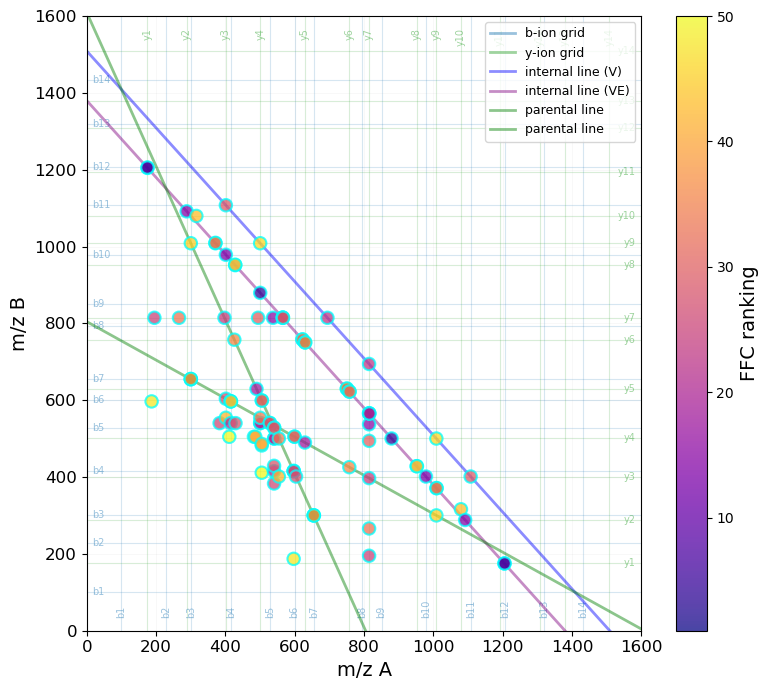

(<Figure size 800x700 with 2 Axes>, <Axes: xlabel='m/z A', ylabel='m/z B'>)

In [811]:
plot_ffc_map_by_grid_type(
    mms_df,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    ranking_col="Ranking",
    lines=exact_lines,
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    grid_label_alpha=0.45,
    grid_label_fontsize=7,
    xlim = (0, 1600),
    ylim = (0, 1600)
)

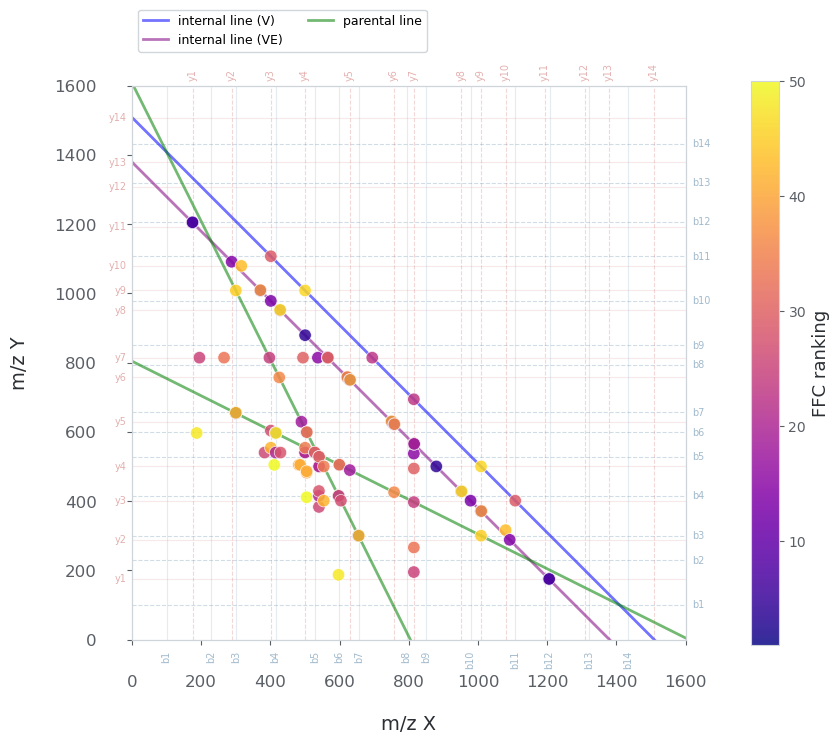

(<Figure size 850x750 with 2 Axes>, <Axes: xlabel='m/z X', ylabel='m/z Y'>)

In [812]:
plot_ffc_map(
    mms_df,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    ranking_col="Ranking",
    lines=exact_lines,
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    grid_alpha=0.12,
    grid_label_alpha=0.45,
    grid_label_fontsize=7,
        xlim = (0, 1600),
    ylim = (0, 1600)
)

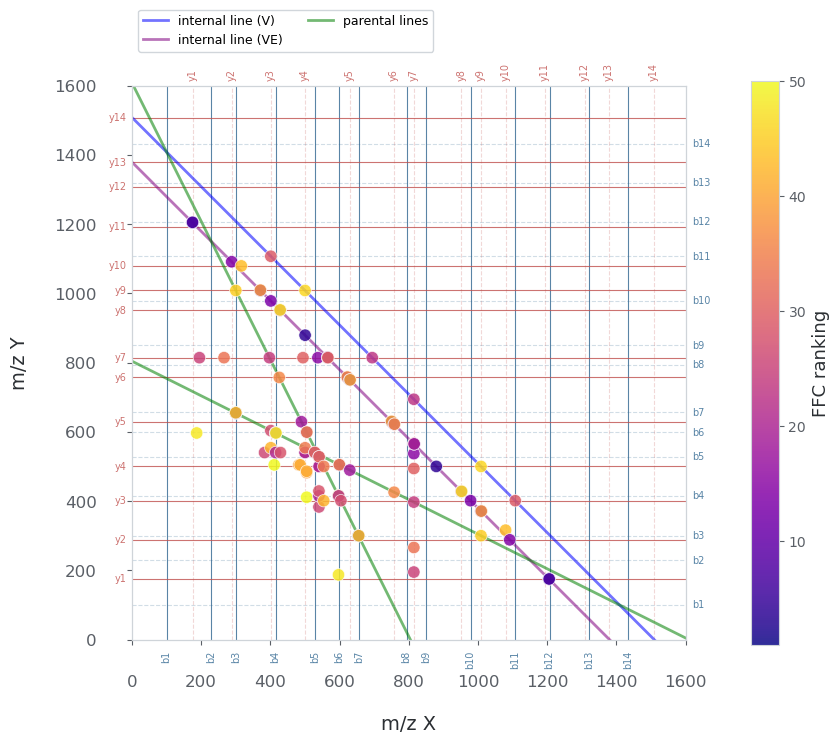

(<Figure size 850x750 with 2 Axes>, <Axes: xlabel='m/z X', ylabel='m/z Y'>)

In [813]:
exact_lines = [
    {"slope": -1, "intercept": 1608.869-100.069, "color": "blue", "label": "internal line (V)"},
    {"slope": -1, "intercept": 1608.869 - 229.112, "color": "purple", "label": "internal line (VE)"},
    {"slope": -0.5, "intercept": 1608.869/2, "color": "green", "label": "parental lines"},
    {"slope": -2, "intercept": 1608.869, "color": "green", "label": "parental lines"}
]




plot_ffc_map(
    mms_df,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    ranking_col="Ranking",
    lines=exact_lines,
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    grid_alpha=0.8,
    grid_label_alpha=0.8,
    grid_label_fontsize=7,
    xlim = (0, 1600),
    ylim = (0, 1600)
)

In [814]:
int_lines = [
    {"slope": -1, "intercept": 1608.869-100.069, "color": "blue", "label": "internal line (V)"},
    {"slope": -1, "intercept": 1608.869 - 229.112, "color": "purple", "label": "internal line (VE)"},
]

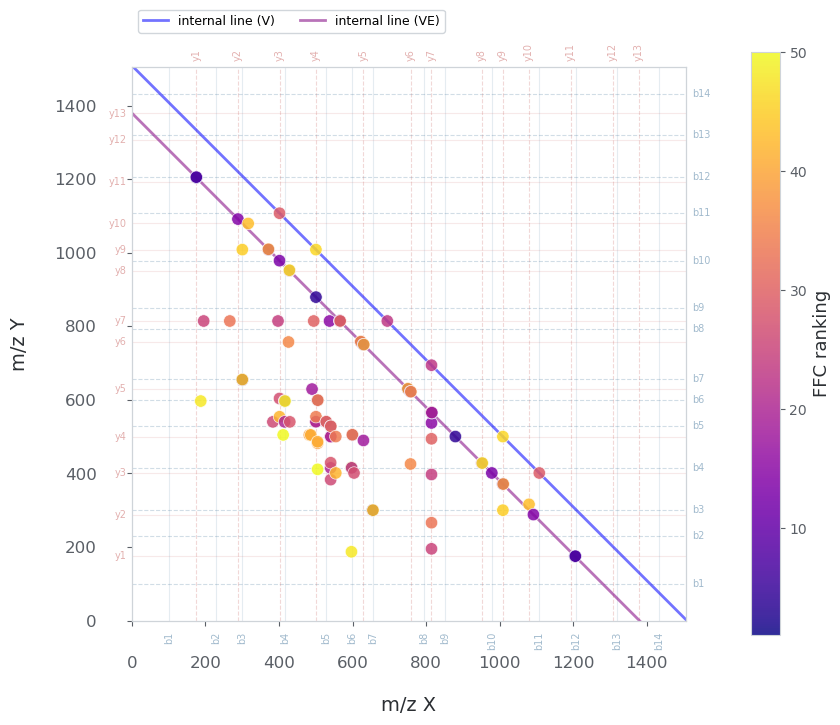

(<Figure size 850x750 with 2 Axes>, <Axes: xlabel='m/z X', ylabel='m/z Y'>)

In [815]:
plot_ffc_map(
    mms_df,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    ranking_col="Ranking",
    lines=int_lines,
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    grid_alpha=0.12,
    grid_label_alpha=0.45,
    grid_label_fontsize=7
)

In [816]:
mms_df

,m/z A,m/z B,Ranking,annotation A,annotation B
346,175.119605,1204.639002,1,y1 (+1),internal 3:14 (+1)
347,175.119605,1205.641873,8,y1 (+1),internal 3:14 (+1) (C13)
613,187.072039,596.845575,48,internal 3:4 (+1),y11 (+2)
856,195.088350,814.482029,25,internal 7:8 (+1) / internal 8:9 (+1),y7 (+1)
2248,266.125697,814.482029,33,internal 6:8 (+1) / internal 3:8-H2O-NH3 (+2) ...,y7 (+1)
...,...,...,...,...,...
29250,1079.601791,316.114992,43,y10 (+1),internal 2:4 (+1)
29594,1091.554730,288.204002,14,internal 3:13 (+1),y2 (+1)
29780,1107.512648,401.288604,29,b11 (+1) / internal 2:12 (+1),y3 (+1)
29929,1204.639002,175.119605,1,internal 3:14 (+1),y1 (+1)


In [817]:
mms_df[mms_df['Ranking'] == 39]

,m/z A,m/z B,Ranking,annotation A,annotation B
6840,482.226425,504.784561,39,internal 2:6-H2O (+1) / internal 2:11-H2O-CO (...,y9 (+2)
9435,504.784561,482.226425,39,y9 (+2),internal 2:6-H2O (+1) / internal 2:11-H2O-CO (...


In [818]:
mms_df[mms_df['Ranking'] == 41]

,m/z A,m/z B,Ranking,annotation A,annotation B
7188,486.221220,504.784561,41,No Match,y9 (+2)
9437,504.784561,486.221220,41,y9 (+2),No Match


In [819]:
mms_df[mms_df['Ranking'] == 29]

,m/z A,m/z B,Ranking,annotation A,annotation B
4695,401.288604,1107.512648,29,y3 (+1),b11 (+1) / internal 2:12 (+1)
29780,1107.512648,401.288604,29,b11 (+1) / internal 2:12 (+1),y3 (+1)


In [820]:
mms_df.shape

(100, 5)

In [821]:
b_ions

{'b1': 100.07566,
 'b2': 229.11825,
 'b3': 300.15536,
 'b4': 415.18229999999994,
 'b5': 528.26636,
 'b6': 599.30347,
 'b7': 656.32493,
 'b8': 793.38384,
 'b9': 850.4053,
 'b10': 978.46388,
 'b11': 1107.50647,
 'b12': 1206.5748800000001,
 'b13': 1319.65894,
 'b14': 1432.743}

In [822]:
mms_df.head()

,m/z A,m/z B,Ranking,annotation A,annotation B
346,175.119605,1204.639002,1,y1 (+1),internal 3:14 (+1)
347,175.119605,1205.641873,8,y1 (+1),internal 3:14 (+1) (C13)
613,187.072039,596.845575,48,internal 3:4 (+1),y11 (+2)
856,195.088350,814.482029,25,internal 7:8 (+1) / internal 8:9 (+1),y7 (+1)
2248,266.125697,814.482029,33,internal 6:8 (+1) / internal 3:8-H2O-NH3 (+2) ...,y7 (+1)


In [823]:
#mms_df.to_csv('point_not_line_VEA.csv')

In [824]:
ranking_to_keep = [3, 9, 12, 10, 24, 36, 18, 34, 61, 7, 19, 2, 11, 5, 4, 13, 14, 1, 46, 23, 29] 
df_parent = mms_df[mms_df["Ranking"].isin(ranking_to_keep)].copy()

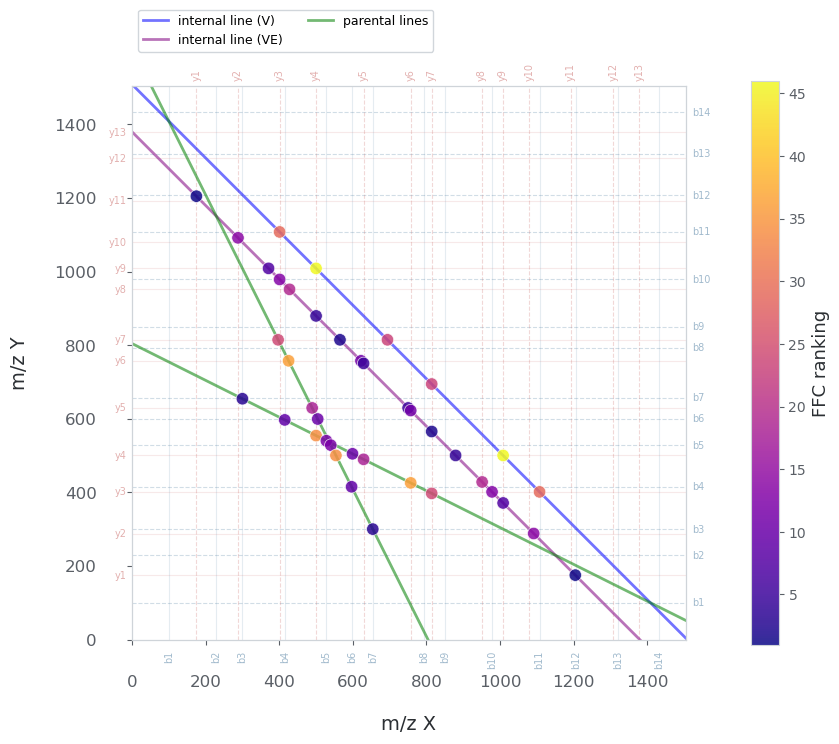

(<Figure size 850x750 with 2 Axes>, <Axes: xlabel='m/z X', ylabel='m/z Y'>)

In [825]:
plot_ffc_map(
    df_parent,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    ranking_col="Ranking",
    lines=exact_lines,
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    grid_alpha=0.12,
    grid_label_alpha=0.45,
    grid_label_fontsize=7
)

In [826]:
df_filtered = mms_df[~mms_df["Ranking"].isin(ranking_to_drop)].copy()

In [827]:
df_filtered.head()

,m/z A,m/z B,Ranking,annotation A,annotation B
613,187.072039,596.845575,48,internal 3:4 (+1),y11 (+2)
856,195.088350,814.482029,25,internal 7:8 (+1) / internal 8:9 (+1),y7 (+1)
2248,266.125697,814.482029,33,internal 6:8 (+1) / internal 3:8-H2O-NH3 (+2) ...,y7 (+1)
2893,300.156407,655.362039,44,b3 (+1) / b6 (+2) / internal 3:5 (+1) / intern...,No Match
3300,316.114992,1079.601791,43,internal 2:4 (+1),y10 (+1)


In [828]:
#df_filtered.to_csv('point_not_line_VEA.csv')

In [829]:
df_annot = pd.read_csv('point_not_line_VEA.csv')
df_annot.head()

,Unnamed: 0,m/z A,m/z B,Ranking,annotation A,annotation B
0,347,175.119605,1205.641873,8,y1 (+1),i(3:14)(+1) (C13)
1,613,187.072039,596.845575,48,i(3:4) (+1),y11 (+2)
2,856,195.088350,814.482029,25,i(7:8) (+1),y7 (+1)
3,2248,266.125697,814.482029,33,i(6:8)(+1),y7 (+1)
4,2892,300.156407,654.860832,6,b3 (+1),y12 (+2) (C13)


In [830]:
df_annot.shape

(60, 6)

In [831]:
df_annot = df_annot[~df_annot["Ranking"].isin(ranking_to_drop)].copy()

In [832]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_ffc_annotation_map_with_table(
    df,
    mz_a_col="mz_A",
    mz_b_col="mz_B",
    ranking_col="ranking",
    mz_a_anno_col="mz_A_annotation",
    mz_b_anno_col="mz_B_annotation",
    b_ions=None,
    y_ions=None,
    xlim=None,
    ylim=None,
    start_from_zero=True,
    make_plot_square=True,
    figsize=(18, 10),
    width_ratios=(1.9, 0.05, 0.75),
    point_size=75,
    point_alpha=0.75,
    point_edgecolor="cyan",
    point_linewidth=1.3,
    cmap="plasma",
    grid_alpha=0.08,
    grid_linewidth=0.7,
    grid_label_alpha=0.25,
    grid_label_fontsize=6,
    show_grid_labels=True,
    number_fontsize=10,
    number_alpha=0.9,
    number_dx=4,
    number_dy=4,
    table_fontsize=7.5,
    table_scale_y=1.18,
    table_col_widths=(0.38, 0.38),
    max_table_rows=None,
    sort_by_ranking=True,
    save_path=None,
):
    """
    Plot an FFC map where each point is labeled by a number.
    The side table lists the mz_A and mz_B annotations.

    The row number of the table corresponds to the point number on the plot.
    """

    data = df.copy()

    required_cols = [
        mz_a_col,
        mz_b_col,
        ranking_col,
        mz_a_anno_col,
        mz_b_anno_col,
    ]

    missing_cols = [col for col in required_cols if col not in data.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    # Convert numeric columns
    data[mz_a_col] = pd.to_numeric(data[mz_a_col], errors="coerce")
    data[mz_b_col] = pd.to_numeric(data[mz_b_col], errors="coerce")
    data[ranking_col] = pd.to_numeric(data[ranking_col], errors="coerce")

    # Clean annotation columns
    data[mz_a_anno_col] = data[mz_a_anno_col].fillna("").astype(str)
    data[mz_b_anno_col] = data[mz_b_anno_col].fillna("").astype(str)

    # Remove invalid rows
    data = data.dropna(subset=[mz_a_col, mz_b_col, ranking_col])

    if data.empty:
        raise ValueError("No valid data points remain after cleaning the dataframe.")

    # Sort and assign point numbers
    if sort_by_ranking:
        data = data.sort_values(ranking_col).reset_index(drop=True)
    else:
        data = data.reset_index(drop=True)

    data["annotation_no"] = range(1, len(data) + 1)

    # Determine plot ranges
    if xlim is None:
        if start_from_zero:
            xlim = (0, data[mz_a_col].max() + 50)
        else:
            xlim = (
                data[mz_a_col].min() - 50,
                data[mz_a_col].max() + 50,
            )

    if ylim is None:
        if start_from_zero:
            ylim = (0, data[mz_b_col].max() + 50)
        else:
            ylim = (
                data[mz_b_col].min() - 50,
                data[mz_b_col].max() + 50,
            )

    # Force the same x/y range for a square data-scale plot
    if make_plot_square:
        max_limit = max(xlim[1], ylim[1])
        xlim = (xlim[0], max_limit)
        ylim = (ylim[0], max_limit)

    # ------------------------------------------------------------
    # Create custom layout:
    # plot | colorbar | table
    # ------------------------------------------------------------

    fig = plt.figure(figsize=figsize)

    gs = fig.add_gridspec(
        1,
        3,
        width_ratios=width_ratios,
        wspace=0.18,
    )

    ax = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])
    ax_table = fig.add_subplot(gs[0, 2])

    # ------------------------------------------------------------
    # Faint b/y ion grid
    # ------------------------------------------------------------

    b_label_y = ylim[0] + 0.015 * (ylim[1] - ylim[0])
    y_label_x = xlim[0] + 0.008 * (xlim[1] - xlim[0])

    if b_ions is not None:
        for ion_name, mz_value in b_ions.items():
            mz_value = float(mz_value)

            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(
                    x=mz_value,
                    color="gray",
                    alpha=grid_alpha,
                    linewidth=grid_linewidth,
                    zorder=0,
                )

                if show_grid_labels:
                    ax.text(
                        mz_value,
                        b_label_y,
                        ion_name,
                        color="gray",
                        alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        rotation=90,
                        ha="center",
                        va="bottom",
                        zorder=1,
                    )

    if y_ions is not None:
        for ion_name, mz_value in y_ions.items():
            mz_value = float(mz_value)

            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(
                    y=mz_value,
                    color="gray",
                    alpha=grid_alpha,
                    linewidth=grid_linewidth,
                    zorder=0,
                )

                if show_grid_labels:
                    ax.text(
                        y_label_x,
                        mz_value,
                        ion_name,
                        color="gray",
                        alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        ha="left",
                        va="center",
                        zorder=1,
                    )

    # ------------------------------------------------------------
    # Scatter plot
    # ------------------------------------------------------------

    scatter = ax.scatter(
        data[mz_a_col],
        data[mz_b_col],
        c=data[ranking_col],
        cmap=cmap,
        s=point_size,
        edgecolors=point_edgecolor,
        linewidths=point_linewidth,
        alpha=point_alpha,
        zorder=3,
    )

    cbar = fig.colorbar(scatter, cax=cax)
    cbar.set_label("FFC ranking", fontsize=13)

    # ------------------------------------------------------------
    # Number labels on points
    # ------------------------------------------------------------

    for _, row in data.iterrows():
        ax.annotate(
            str(int(row["annotation_no"])),
            xy=(row[mz_a_col], row[mz_b_col]),
            xytext=(number_dx, number_dy),
            textcoords="offset points",
            fontsize=number_fontsize,
            alpha=number_alpha,
            ha="left",
            va="bottom",
            zorder=4,
            clip_on=True,
        )

    # ------------------------------------------------------------
    # Axis formatting
    # ------------------------------------------------------------

    ax.set_xlabel("m/z A", fontsize=14)
    ax.set_ylabel("m/z B", fontsize=14)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    if make_plot_square:
        ax.set_aspect("equal", adjustable="box")

    ax.tick_params(axis="both", labelsize=12)
    ax.grid(True, alpha=0.18, linewidth=0.5)

    # ------------------------------------------------------------
    # Side annotation table
    # ------------------------------------------------------------

    ax_table.axis("off")

    table_data = data.copy()

    if max_table_rows is not None:
        table_data = table_data.head(max_table_rows)

    table_rows = []

    for _, row in table_data.iterrows():
        table_rows.append([
            row[mz_a_anno_col],
            row[mz_b_anno_col],
        ])

    col_labels = ["m/z A annotation", "m/z B annotation"]

    table = ax_table.table(
        cellText=table_rows,
        colLabels=col_labels,
        rowLabels=[str(i) for i in table_data["annotation_no"]],
        cellLoc="left",
        colLoc="left",
        rowLoc="center",
        loc="center",
        colWidths=table_col_widths,
        bbox=[0, 0, 1, 1],   # fill the table panel
    )

    table.auto_set_font_size(False)
    table.set_fontsize(table_fontsize)
    table.scale(1.0, table_scale_y)

    # Style table
    for (row_idx, col_idx), cell in table.get_celld().items():
        cell.set_edgecolor("gray")
        cell.set_linewidth(0.35)

        if row_idx == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#f2f2f2")
        else:
            cell.set_facecolor("white")

    # Improve spacing around the whole figure
    fig.subplots_adjust(
        left=0.055,
        right=0.985,
        bottom=0.08,
        top=0.97,
        wspace=0.18,
    )

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return fig, ax, ax_table, data

/Users/kevinmbp/miniforge3/envs/2d_spec/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


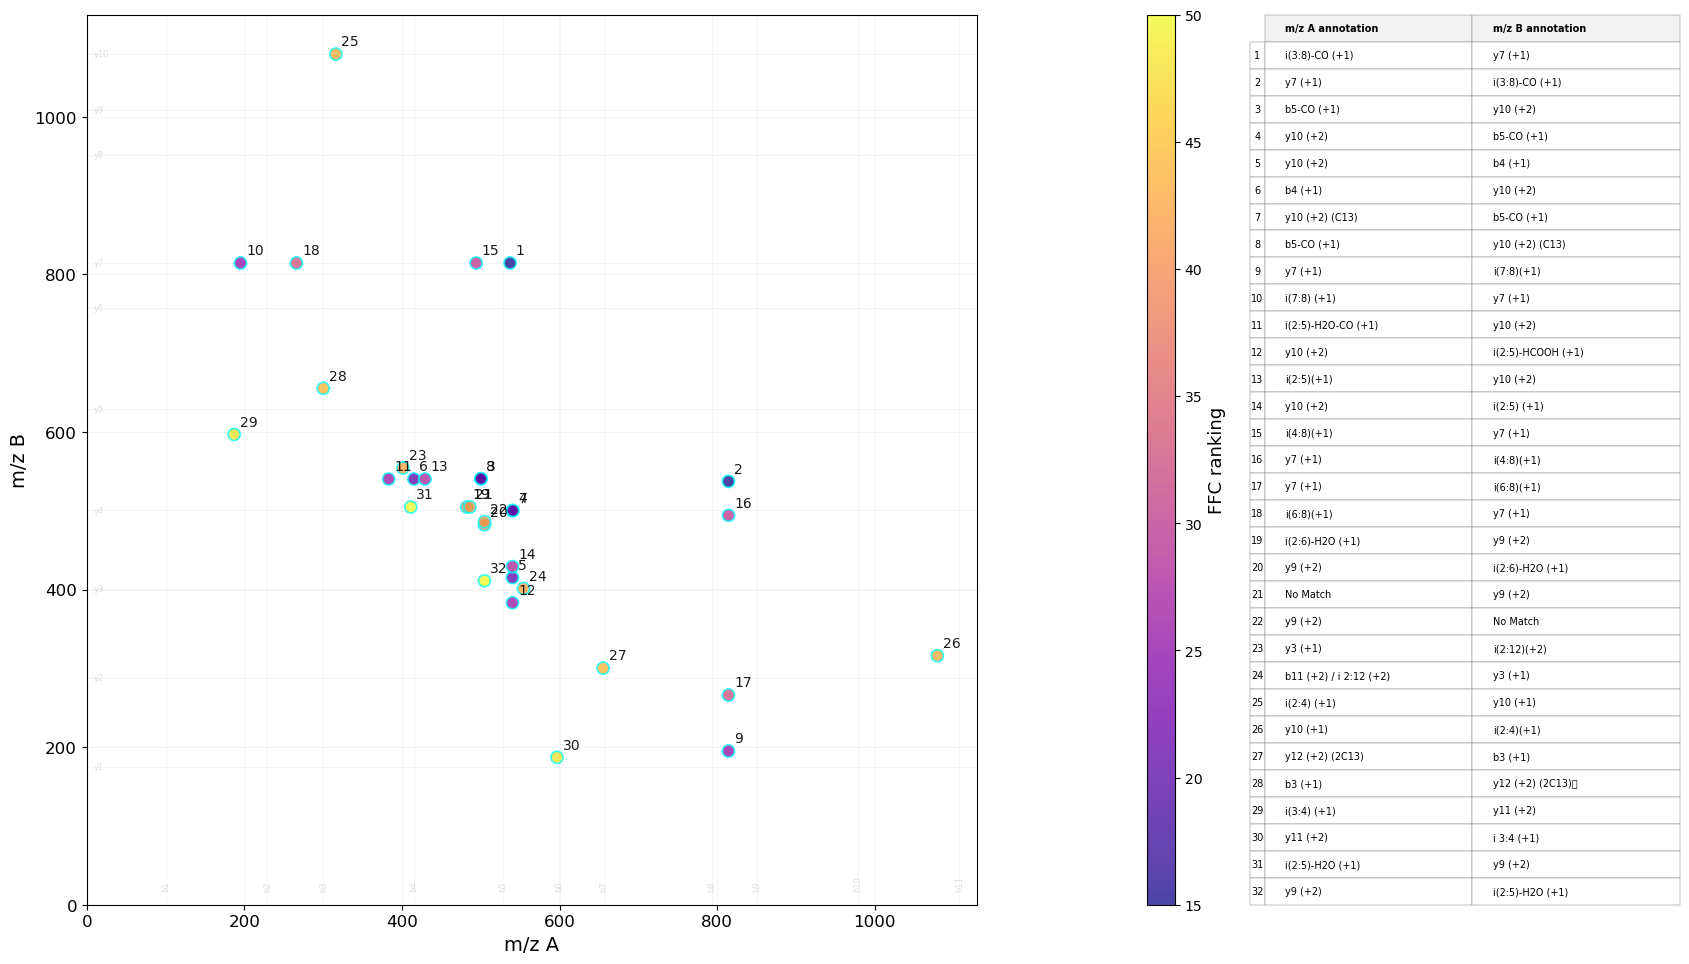

In [833]:
fig, ax, ax_table, annotated_df = plot_ffc_annotation_map_with_table(
    df_annot,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    ranking_col="Ranking",
    mz_a_anno_col="annotation A",
    mz_b_anno_col="annotation B",
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    sort_by_ranking=True,
    table_fontsize=7,
)

In [834]:
#ranking_to_drop = [3, 9, 12, 10, 24, 36, 18, 34, 61, 7, 19, 2, 11, 5, 4, 13, 14, 1, 46, 23, 29, 6, 22, 32, 35, 63, 77, 72, 52, 38,47,17,37,40,8,48, 45, 49,] 
ranking_to_drop = [3, 9, 10, 12, 18, 24, 27, 34, 36, 45, 6, 22, 32, 35, 49, 1, 1, 2, 2, 4, 4, 5, 5, 7, 7, 11, 11, 13, 13, 14, 14, 19, 19, 8, 8, 17, 17, 31, 31, 37, 37, 38, 38, 40, 40, 47, 47, 23, 23, 29, 29, 46, 46]


In [835]:
len(ranking_to_drop)

53

In [836]:
df_annot = df_annot[~df_annot["Ranking"].isin(ranking_to_drop)].copy()

In [837]:
sum(np.array(ranking_to_drop) > 50)


np.int64(0)

In [838]:
df_annot

,Unnamed: 0,m/z A,m/z B,Ranking,annotation A,annotation B
1,613,187.072039,596.845575,48,i(3:4) (+1),y11 (+2)
2,856,195.088350,814.482029,25,i(7:8) (+1),y7 (+1)
3,2248,266.125697,814.482029,33,i(6:8)(+1),y7 (+1)
5,2893,300.156407,655.362039,44,b3 (+1),y12 (+2) (2C13)\t
7,3300,316.114992,1079.601791,43,i(2:4) (+1),y10 (+1)
9,3562,383.194391,540.303260,26,i(2:5)-H2O-CO (+1),y10 (+2)
10,4609,401.288604,554.258768,42,y3 (+1),i(2:12)(+2)
11,4926,411.188975,504.784561,50,i(2:5)-H2O (+1),y9 (+2)
12,5128,415.183883,540.303260,20,b4 (+1),y10 (+2)
17,5824,429.199500,540.303260,28,i(2:5)(+1),y10 (+2)


/Users/kevinmbp/miniforge3/envs/2d_spec/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


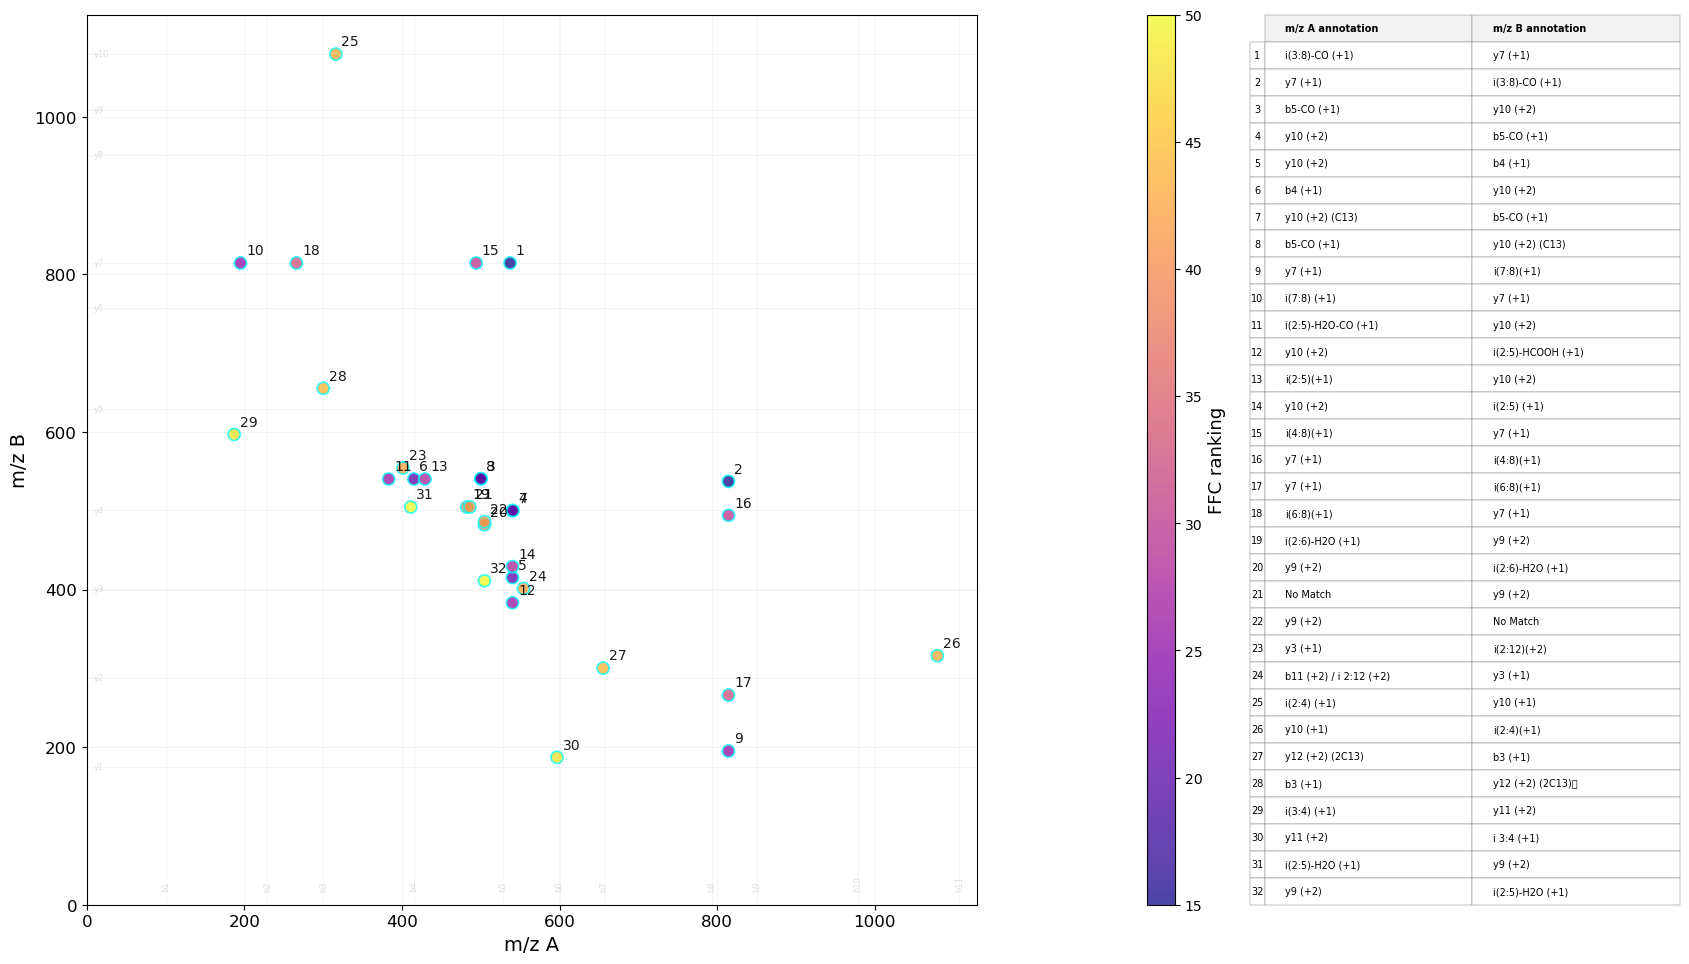

In [839]:
fig, ax, ax_table, annotated_df = plot_ffc_annotation_map_with_table(
    df_annot,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    ranking_col="Ranking",
    mz_a_anno_col="annotation A",
    mz_b_anno_col="annotation B",
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    sort_by_ranking=True,
    table_fontsize=7,
)

In [840]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_ffc_annotation_map_with_table(
    df,
    mz_a_col="mz_A",
    mz_b_col="mz_B",
    ranking_col="ranking",
    mz_a_anno_col="mz_A_annotation",
    mz_b_anno_col="mz_B_annotation",
    b_ions=None,
    y_ions=None,
    xlim=None,
    ylim=None,
    start_from_zero=True,
    make_plot_square=True,
    figsize=(18, 10),
    width_ratios=(1.9, 0.05, 0.75),
    point_size=75,
    point_alpha=0.75,
    point_edgecolor="cyan",
    point_linewidth=1.3,
    cmap="plasma",
    grid_alpha=0.08,
    grid_linewidth=0.7,
    grid_label_alpha=0.25,
    grid_label_fontsize=6,
    show_grid_labels=True,
    number_fontsize=10,
    number_alpha=0.9,
    number_dx=4,
    number_dy=4,
    table_fontsize=7.5,
    table_scale_y=1.18,
    table_col_widths=(0.38, 0.38),
    max_table_rows=None,
    sort_by_ranking=True,
    save_path=None,
):
    """
    Plot an FFC map where each point is labeled by its FFC ranking.
    The side table lists the mz_A and mz_B annotations.

    The row label of the table is the FFC ranking.
    Some rows may share the same ranking, for example when the x/y coordinates are switched.
    """

    def format_ranking_value(value):
        """Format ranking cleanly as an integer when possible."""
        if pd.isna(value):
            return ""
        value = float(value)
        if value.is_integer():
            return str(int(value))
        return str(value)

    data = df.copy()

    required_cols = [
        mz_a_col,
        mz_b_col,
        ranking_col,
        mz_a_anno_col,
        mz_b_anno_col,
    ]

    missing_cols = [col for col in required_cols if col not in data.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    # Convert numeric columns
    data[mz_a_col] = pd.to_numeric(data[mz_a_col], errors="coerce")
    data[mz_b_col] = pd.to_numeric(data[mz_b_col], errors="coerce")
    data[ranking_col] = pd.to_numeric(data[ranking_col], errors="coerce")

    # Clean annotation columns
    data[mz_a_anno_col] = data[mz_a_anno_col].fillna("").astype(str)
    data[mz_b_anno_col] = data[mz_b_anno_col].fillna("").astype(str)

    # Remove invalid rows
    data = data.dropna(subset=[mz_a_col, mz_b_col, ranking_col])

    if data.empty:
        raise ValueError("No valid data points remain after cleaning the dataframe.")

    # Sort by ranking if requested
    if sort_by_ranking:
        data = data.sort_values(ranking_col).reset_index(drop=True)
    else:
        data = data.reset_index(drop=True)

    # Determine plot ranges
    if xlim is None:
        if start_from_zero:
            xlim = (0, data[mz_a_col].max() + 50)
        else:
            xlim = (
                data[mz_a_col].min() - 50,
                data[mz_a_col].max() + 50,
            )

    if ylim is None:
        if start_from_zero:
            ylim = (0, data[mz_b_col].max() + 50)
        else:
            ylim = (
                data[mz_b_col].min() - 50,
                data[mz_b_col].max() + 50,
            )

    # Force the same x/y range for a square data-scale plot
    if make_plot_square:
        max_limit = max(xlim[1], ylim[1])
        xlim = (xlim[0], max_limit)
        ylim = (ylim[0], max_limit)

    # ------------------------------------------------------------
    # Create custom layout:
    # plot | colorbar | table
    # ------------------------------------------------------------

    fig = plt.figure(figsize=figsize)

    gs = fig.add_gridspec(
        1,
        3,
        width_ratios=width_ratios,
        wspace=0.18,
    )

    ax = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])
    ax_table = fig.add_subplot(gs[0, 2])

    # ------------------------------------------------------------
    # Faint b/y ion grid
    # ------------------------------------------------------------

    b_label_y = ylim[0] + 0.015 * (ylim[1] - ylim[0])
    y_label_x = xlim[0] + 0.008 * (xlim[1] - xlim[0])

    if b_ions is not None:
        for ion_name, mz_value in b_ions.items():
            mz_value = float(mz_value)

            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(
                    x=mz_value,
                    color="gray",
                    alpha=grid_alpha,
                    linewidth=grid_linewidth,
                    zorder=0,
                )

                if show_grid_labels:
                    ax.text(
                        mz_value,
                        b_label_y,
                        ion_name,
                        color="gray",
                        alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        rotation=90,
                        ha="center",
                        va="bottom",
                        zorder=1,
                    )

    if y_ions is not None:
        for ion_name, mz_value in y_ions.items():
            mz_value = float(mz_value)

            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(
                    y=mz_value,
                    color="gray",
                    alpha=grid_alpha,
                    linewidth=grid_linewidth,
                    zorder=0,
                )

                if show_grid_labels:
                    ax.text(
                        y_label_x,
                        mz_value,
                        ion_name,
                        color="gray",
                        alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        ha="left",
                        va="center",
                        zorder=1,
                    )

    # ------------------------------------------------------------
    # Scatter plot
    # ------------------------------------------------------------

    scatter = ax.scatter(
        data[mz_a_col],
        data[mz_b_col],
        c=data[ranking_col],
        cmap=cmap,
        s=point_size,
        edgecolors=point_edgecolor,
        linewidths=point_linewidth,
        alpha=point_alpha,
        zorder=3,
    )

    cbar = fig.colorbar(scatter, cax=cax)
    cbar.set_label("FFC ranking", fontsize=13)

    # ------------------------------------------------------------
    # Ranking labels on points
    # ------------------------------------------------------------

    for _, row in data.iterrows():
        ax.annotate(
            format_ranking_value(row[ranking_col]),
            xy=(row[mz_a_col], row[mz_b_col]),
            xytext=(number_dx, number_dy),
            textcoords="offset points",
            fontsize=number_fontsize,
            alpha=number_alpha,
            ha="left",
            va="bottom",
            zorder=4,
            clip_on=True,
        )

    # ------------------------------------------------------------
    # Axis formatting
    # ------------------------------------------------------------

    ax.set_xlabel("m/z A", fontsize=14)
    ax.set_ylabel("m/z B", fontsize=14)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    if make_plot_square:
        ax.set_aspect("equal", adjustable="box")

    ax.tick_params(axis="both", labelsize=12)
    ax.grid(True, alpha=0.18, linewidth=0.5)

    # ------------------------------------------------------------
    # Side annotation table
    # ------------------------------------------------------------

    ax_table.axis("off")

    table_data = data.copy()

    if max_table_rows is not None:
        table_data = table_data.head(max_table_rows)

    table_rows = []

    for _, row in table_data.iterrows():
        table_rows.append([
            row[mz_a_anno_col],
            row[mz_b_anno_col],
        ])

    col_labels = ["m/z A annotation", "m/z B annotation"]

    table = ax_table.table(
        cellText=table_rows,
        colLabels=col_labels,
        rowLabels=[format_ranking_value(v) for v in table_data[ranking_col]],
        cellLoc="left",
        colLoc="left",
        rowLoc="center",
        loc="center",
        colWidths=table_col_widths,
        bbox=[0, 0, 1, 1],
    )

    table.auto_set_font_size(False)
    table.set_fontsize(table_fontsize)
    table.scale(1.0, table_scale_y)

    # Style table
    for (row_idx, col_idx), cell in table.get_celld().items():
        cell.set_edgecolor("lightgray")
        cell.set_linewidth(0.35)

        if row_idx == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#f2f2f2")
        else:
            cell.set_facecolor("white")

    # Improve spacing around the whole figure
    fig.subplots_adjust(
        left=0.055,
        right=0.985,
        bottom=0.08,
        top=0.97,
        wspace=0.18,
    )

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return fig, ax, ax_table, data

/Users/kevinmbp/miniforge3/envs/2d_spec/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


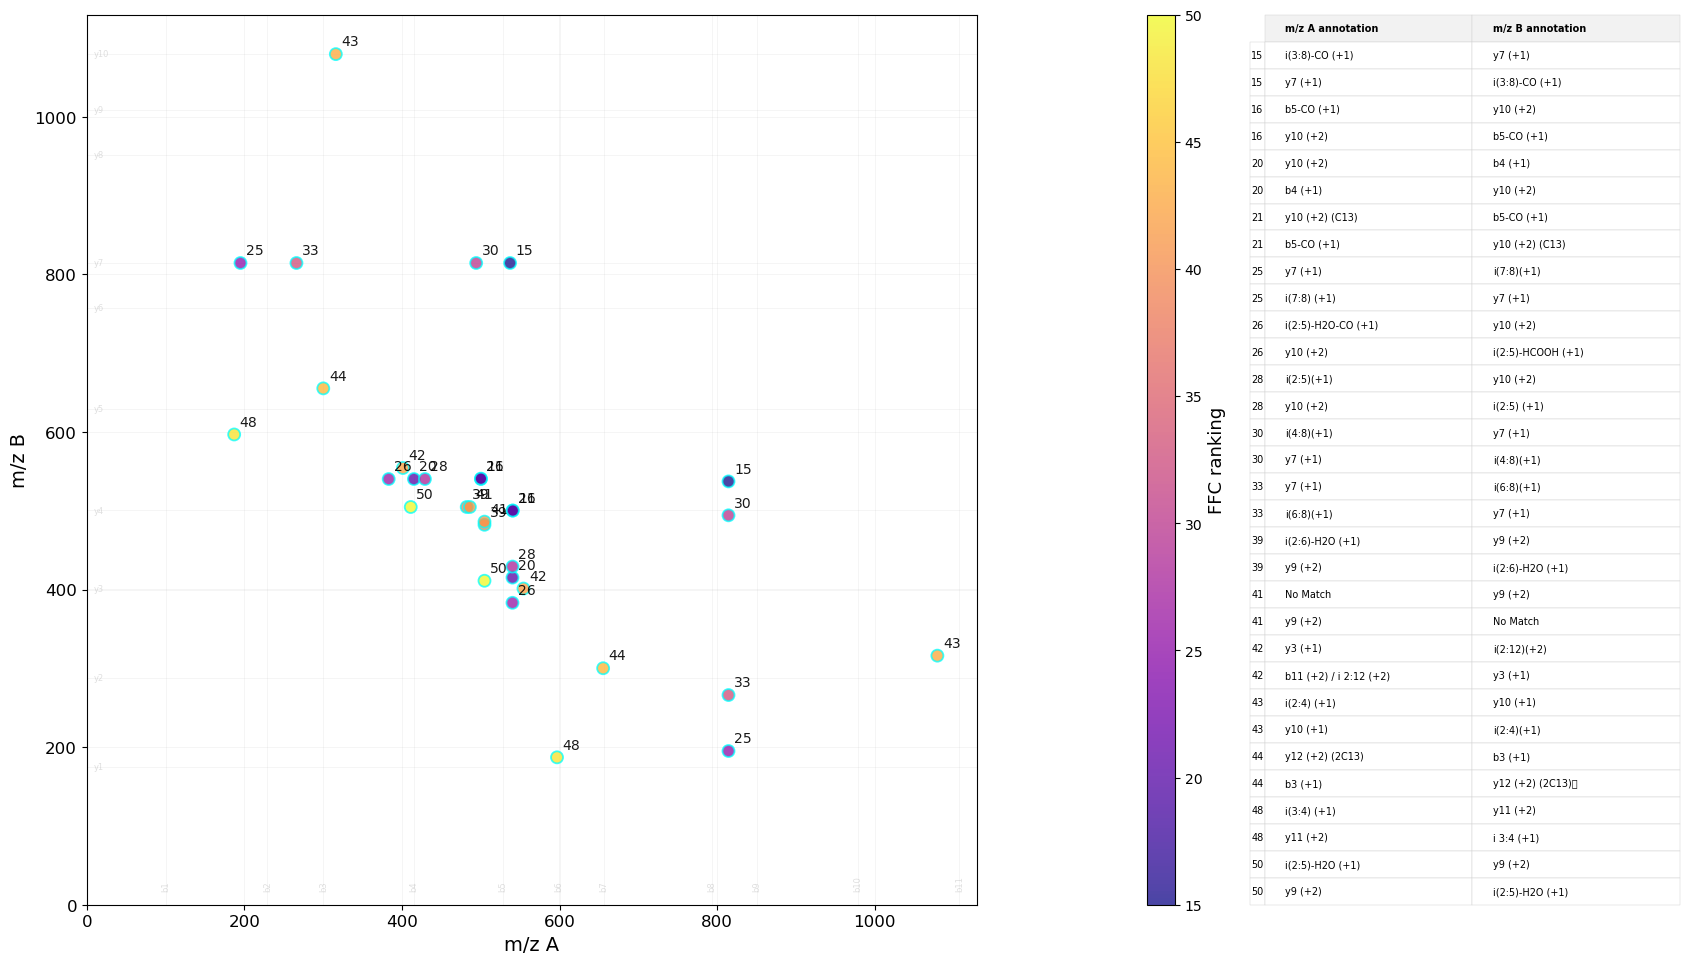

In [841]:
fig, ax, ax_table, annotated_df = plot_ffc_annotation_map_with_table(
    df_annot,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    ranking_col="Ranking",
    mz_a_anno_col="annotation A",
    mz_b_anno_col="annotation B",
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    sort_by_ranking=True,
    table_fontsize=7,
)

In [842]:
import re
import pandas as pd
import matplotlib.pyplot as plt


def plot_ffc_map_with_bottom_annotation_table(
    df,
    mz_a_col="mz_A",
    mz_b_col="mz_B",
    ranking_col="ranking",
    mz_a_anno_col="mz_A_annotation",
    mz_b_anno_col="mz_B_annotation",
    b_ions=None,
    y_ions=None,
    xlim=None,
    ylim=None,
    figsize=(9, 14),
    plot_height_ratio=3.5,
    table_height_ratio=2.2,
    point_size=80,
    point_alpha=0.75,
    point_edgecolor="cyan",
    point_linewidth=1.5,
    cmap="plasma",
    grid_alpha=0.12,
    grid_linewidth=0.8,
    grid_label_alpha=0.35,
    grid_label_fontsize=7,
    show_grid_labels=True,
    background_grid=False,
    force_equal_axis_limits=False,
    number_fontsize=8,
    number_alpha=1.0,
    number_dx=4,
    number_dy=4,
    avoid_label_overlap=True,
    label_offset_points=7,
    label_bin_size=45,
    label_box=True,
    table_fontsize=9,
    table_scale_y=1.35,
    max_table_rows=None,
    sort_by_ranking=True,
    collapse_symmetric_duplicates=True,
    save_path=None,
):
    """
    Plot an FFC map with ranking labels on the points and an annotation table below.

    This version:
    - draws no diagonal/internal/parental lines;
    - draws only b-ion vertical lines on x-axis;
    - draws only y-ion horizontal lines on y-axis;
    - keeps user-provided xlim/ylim unchanged unless force_equal_axis_limits=True;
    - optionally disables the normal background grid.
    """

    def clean_annotation(x):
        if pd.isna(x):
            return ""
        x = str(x).strip()
        x = x.replace("internal", "int")
        return x

    def starts_with_b(anno):
        return bool(re.match(r"^\s*b\d+", anno))

    def starts_with_y(anno):
        return bool(re.match(r"^\s*y\d+", anno))

    def reorder_annotations(anno_a, anno_b):
        anno_a = clean_annotation(anno_a)
        anno_b = clean_annotation(anno_b)

        a_is_y = starts_with_y(anno_a)
        b_is_y = starts_with_y(anno_b)
        a_is_b = starts_with_b(anno_a)
        b_is_b = starts_with_b(anno_b)

        if a_is_y and not b_is_y:
            return anno_b, anno_a

        if b_is_y:
            return anno_a, anno_b

        if a_is_b:
            return anno_a, anno_b

        if b_is_b and not a_is_y:
            return anno_b, anno_a

        return anno_a, anno_b

    def format_ranking_value(value):
        if pd.isna(value):
            return ""
        value = float(value)
        if value.is_integer():
            return str(int(value))
        return str(value)

    def assign_local_label_offsets(data, x_col, y_col, base_offset=7, bin_size=45):
        offset_patterns = [
            ( base_offset,  base_offset),
            (-base_offset,  base_offset),
            ( base_offset, -base_offset),
            (-base_offset, -base_offset),
            ( base_offset,  0),
            (-base_offset,  0),
            ( 0,  base_offset),
            ( 0, -base_offset),
            ( 1.5 * base_offset,  1.5 * base_offset),
            (-1.5 * base_offset,  1.5 * base_offset),
            ( 1.5 * base_offset, -1.5 * base_offset),
            (-1.5 * base_offset, -1.5 * base_offset),
        ]

        label_offsets = []
        temp = data.copy()
        temp["_x_bin"] = (temp[x_col] / bin_size).round().astype(int)
        temp["_y_bin"] = (temp[y_col] / bin_size).round().astype(int)

        group_counter = {}

        for _, row in temp.iterrows():
            key = (row["_x_bin"], row["_y_bin"])
            count = group_counter.get(key, 0)

            dx, dy = offset_patterns[count % len(offset_patterns)]
            label_offsets.append((dx, dy))
            group_counter[key] = count + 1

        return label_offsets

    # ------------------------------------------------------------
    # Clean dataframe
    # ------------------------------------------------------------

    data = df.copy()

    required_cols = [
        mz_a_col,
        mz_b_col,
        ranking_col,
        mz_a_anno_col,
        mz_b_anno_col,
    ]

    missing_cols = [col for col in required_cols if col not in data.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    data[mz_a_col] = pd.to_numeric(data[mz_a_col], errors="coerce")
    data[mz_b_col] = pd.to_numeric(data[mz_b_col], errors="coerce")
    data[ranking_col] = pd.to_numeric(data[ranking_col], errors="coerce")

    data[mz_a_anno_col] = data[mz_a_anno_col].apply(clean_annotation)
    data[mz_b_anno_col] = data[mz_b_anno_col].apply(clean_annotation)

    data = data.dropna(subset=[mz_a_col, mz_b_col, ranking_col])

    if data.empty:
        raise ValueError("No valid data points remain after cleaning the dataframe.")

    # ------------------------------------------------------------
    # Reorder annotation pair so y-ion is second when possible
    # ------------------------------------------------------------

    ordered_pairs = data.apply(
        lambda row: reorder_annotations(
            row[mz_a_anno_col],
            row[mz_b_anno_col],
        ),
        axis=1,
    )

    data["annotation_1"] = [p[0] for p in ordered_pairs]
    data["annotation_2"] = [p[1] for p in ordered_pairs]

    # ------------------------------------------------------------
    # Remove symmetric duplicates
    # ------------------------------------------------------------

    if collapse_symmetric_duplicates:
        data["annotation_pair_key"] = data.apply(
            lambda row: tuple(sorted([row["annotation_1"], row["annotation_2"]])),
            axis=1,
        )

        data = (
            data.sort_values(ranking_col)
            .drop_duplicates(
                subset=[ranking_col, "annotation_pair_key"],
                keep="first",
            )
            .reset_index(drop=True)
        )

    if sort_by_ranking:
        data = data.sort_values(ranking_col).reset_index(drop=True)
    else:
        data = data.reset_index(drop=True)

    # ------------------------------------------------------------
    # Determine plot ranges
    # ------------------------------------------------------------

    if xlim is None:
        xlim = (data[mz_a_col].min() - 50, data[mz_a_col].max() + 50)

    if ylim is None:
        ylim = (data[mz_b_col].min() - 50, data[mz_b_col].max() + 50)

    # Only force equal x/y numeric limits when requested.
    # This is OFF by default so the scale stays the same as the previous figure.
    if force_equal_axis_limits:
        min_limit = min(xlim[0], ylim[0])
        max_limit = max(xlim[1], ylim[1])
        xlim = (min_limit, max_limit)
        ylim = (min_limit, max_limit)

    # ------------------------------------------------------------
    # Create layout: plot on top, table below
    # ------------------------------------------------------------

    fig = plt.figure(figsize=figsize)

    gs = fig.add_gridspec(
        2,
        1,
        height_ratios=[plot_height_ratio, table_height_ratio],
        hspace=0.30,
    )

    ax = fig.add_subplot(gs[0, 0])
    ax_table = fig.add_subplot(gs[1, 0])

    # ------------------------------------------------------------
    # Add b/y ion grid lines
    # Only b-ions on x-axis and y-ions on y-axis
    # ------------------------------------------------------------

    b_label_y = ylim[0] + 0.02 * (ylim[1] - ylim[0])
    y_label_x = xlim[0] + 0.01 * (xlim[1] - xlim[0])

    if b_ions is not None:
        for ion_name, mz_value in b_ions.items():
            mz_value = float(mz_value)

            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(
                    x=mz_value,
                    color="gray",
                    alpha=grid_alpha,
                    linewidth=grid_linewidth,
                    zorder=0,
                )

                if show_grid_labels:
                    ax.text(
                        mz_value,
                        b_label_y,
                        ion_name,
                        color="gray",
                        alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        rotation=90,
                        ha="center",
                        va="bottom",
                        zorder=1,
                    )

    if y_ions is not None:
        for ion_name, mz_value in y_ions.items():
            mz_value = float(mz_value)

            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(
                    y=mz_value,
                    color="gray",
                    alpha=grid_alpha,
                    linewidth=grid_linewidth,
                    zorder=0,
                )

                if show_grid_labels:
                    ax.text(
                        y_label_x,
                        mz_value,
                        ion_name,
                        color="gray",
                        alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        ha="left",
                        va="center",
                        zorder=1,
                    )

    # ------------------------------------------------------------
    # Scatter plot
    # ------------------------------------------------------------

    scatter = ax.scatter(
        data[mz_a_col],
        data[mz_b_col],
        c=data[ranking_col],
        cmap=cmap,
        s=point_size,
        edgecolors=point_edgecolor,
        linewidths=point_linewidth,
        alpha=point_alpha,
        zorder=3,
    )

    cbar = fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label("FFC ranking", fontsize=14)

    # ------------------------------------------------------------
    # Ranking labels on points with local offsets
    # ------------------------------------------------------------

    if avoid_label_overlap:
        label_offsets = assign_local_label_offsets(
            data,
            mz_a_col,
            mz_b_col,
            base_offset=label_offset_points,
            bin_size=label_bin_size,
        )
    else:
        label_offsets = [(number_dx, number_dy)] * len(data)

    bbox = None
    if label_box:
        bbox = dict(
            boxstyle="round,pad=0.08",
            facecolor="white",
            edgecolor="none",
            alpha=0.55,
        )

    for (_, row), (dx, dy) in zip(data.iterrows(), label_offsets):
        ax.annotate(
            format_ranking_value(row[ranking_col]),
            xy=(row[mz_a_col], row[mz_b_col]),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=number_fontsize,
            alpha=number_alpha,
            ha="center",
            va="center",
            zorder=4,
            clip_on=True,
            bbox=bbox,
        )

    # ------------------------------------------------------------
    # Axis formatting
    # ------------------------------------------------------------

    ax.set_xlabel("m/z A", fontsize=14)
    ax.set_ylabel("m/z B", fontsize=14)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Keep 1:1 data aspect, but do not change xlim/ylim.
    ax.set_aspect("equal", adjustable="box")

    ax.tick_params(axis="both", labelsize=12)

    if background_grid:
        ax.grid(True, alpha=0.12, linewidth=0.5)

    # ------------------------------------------------------------
    # Bottom annotation table
    # ------------------------------------------------------------

    ax_table.axis("off")

    table_data = data.copy()
    
    table_data = (
        table_data
        .sort_values(ranking_col)
        .drop_duplicates(subset=[ranking_col], keep="first")
        .reset_index(drop=True)
    )

    if max_table_rows is not None:
        table_data = table_data.head(max_table_rows)

    table_rows = []

    for _, row in table_data.iterrows():
        table_rows.append([
            format_ranking_value(row[ranking_col]),
            row["annotation_1"],
            row["annotation_2"],
        ])

    col_labels = [
        "FFC ranking",
        "Annotation 1",
        "Annotation 2 / y-ion when present",
    ]

    table = ax_table.table(
        cellText=table_rows,
        colLabels=col_labels,
        cellLoc="left",
        colLoc="left",
        loc="center",
        colWidths=[0.12, 0.40, 0.48],
        bbox=[0, 0, 1, 1],
    )

    table.auto_set_font_size(False)
    table.set_fontsize(table_fontsize)
    table.scale(1.0, table_scale_y)

    for (row_idx, col_idx), cell in table.get_celld().items():
        cell.set_edgecolor("lightgray")
        cell.set_linewidth(0.35)

        if row_idx == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#f2f2f2")
        else:
            cell.set_facecolor("white")

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return fig, ax, ax_table, data

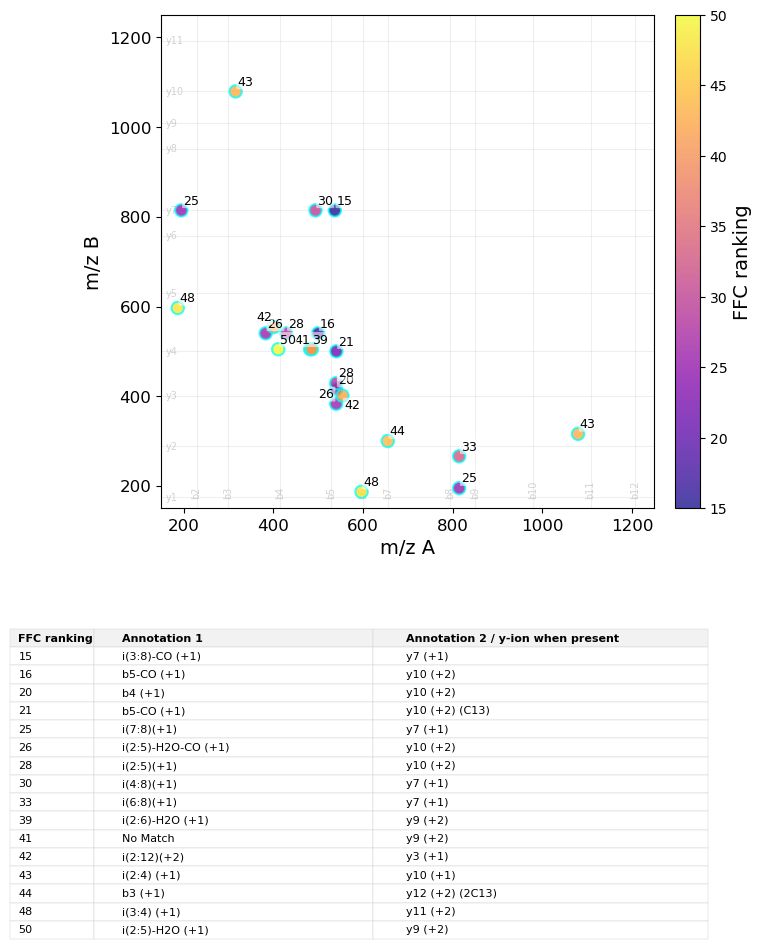

In [843]:
b_ions = {f'b{i}':pep.ion_mass(f'b{i}') for i in range(1, len(PEP_SEQ))}
y_ions = {f'y{i}':pep.ion_mass(f'y{i}') for i in range(1, len(PEP_SEQ))}
df_annot = df_annot[~df_annot["Ranking"].isin(ranking_to_drop)].copy()

fig, ax, ax_table, annotated_df = plot_ffc_map_with_bottom_annotation_table(
    df_annot,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    ranking_col="Ranking",
    mz_a_anno_col="annotation A",
    mz_b_anno_col="annotation B",
    b_ions=b_ions,
    y_ions=y_ions,
    xlim=(150, 1250),
    ylim=(150, 1250),
    figsize=(9, 12),
    number_fontsize=9,
    table_fontsize=8,
)

In [844]:
import re
import pandas as pd
import matplotlib.pyplot as plt


def plot_ffc_map_with_bottom_annotation_table(
    df,
    mz_a_col="mz_A",
    mz_b_col="mz_B",
    ranking_col="ranking",
    mz_a_anno_col="mz_A_annotation",
    mz_b_anno_col="mz_B_annotation",
    b_ions=None,
    y_ions=None,
    xlim=None,
    ylim=None,
    start_from_zero=True,
    figsize=(9, 14),
    plot_height_ratio=3.5,
    table_height_ratio=2.2,
    point_size=80,
    point_alpha=0.75,
    point_edgecolor="cyan",
    point_linewidth=1.5,
    cmap="plasma",
    grid_alpha=0.12,
    grid_linewidth=0.8,
    grid_label_alpha=0.35,
    grid_label_fontsize=7,
    show_grid_labels=True,
    background_grid=False,
    force_equal_axis_limits=False,
    number_fontsize=8,
    number_alpha=1.0,
    number_dx=4,
    number_dy=4,
    avoid_label_overlap=True,
    label_offset_points=7,
    label_bin_size=45,
    label_box=True,
    table_fontsize=9,
    table_scale_y=1.35,
    max_table_rows=None,
    sort_by_ranking=True,
    table_unique_ranking=True,
    save_path=None,
):
    """
    Plot an FFC map with ranking labels on the points and an annotation table below.

    Important behavior:
    - The plotted points keep both (X, Y) and (Y, X).
    - The bottom table can keep only one row per ranking.
    - The graph starts from (0, 0) by default.
    - Only b-ion vertical lines are drawn on the x-axis.
    - Only y-ion horizontal lines are drawn on the y-axis.
    """

    def clean_annotation(x):
        if pd.isna(x):
            return ""
        x = str(x).strip()
        x = x.replace("internal", "int")
        return x

    def starts_with_b(anno):
        return bool(re.match(r"^\s*b\d+", anno))

    def starts_with_y(anno):
        return bool(re.match(r"^\s*y\d+", anno))

    def reorder_annotations(anno_a, anno_b):
        """
        Reorder annotation pair so that the y-ion appears second when possible.
        """
        anno_a = clean_annotation(anno_a)
        anno_b = clean_annotation(anno_b)

        a_is_y = starts_with_y(anno_a)
        b_is_y = starts_with_y(anno_b)
        a_is_b = starts_with_b(anno_a)
        b_is_b = starts_with_b(anno_b)

        if a_is_y and not b_is_y:
            return anno_b, anno_a

        if b_is_y:
            return anno_a, anno_b

        if a_is_b:
            return anno_a, anno_b

        if b_is_b and not a_is_y:
            return anno_b, anno_a

        return anno_a, anno_b

    def format_ranking_value(value):
        if pd.isna(value):
            return ""
        value = float(value)
        if value.is_integer():
            return str(int(value))
        return str(value)

    def assign_local_label_offsets(data, x_col, y_col, base_offset=7, bin_size=45):
        offset_patterns = [
            ( base_offset,  base_offset),
            (-base_offset,  base_offset),
            ( base_offset, -base_offset),
            (-base_offset, -base_offset),
            ( base_offset,  0),
            (-base_offset,  0),
            ( 0,  base_offset),
            ( 0, -base_offset),
            ( 1.5 * base_offset,  1.5 * base_offset),
            (-1.5 * base_offset,  1.5 * base_offset),
            ( 1.5 * base_offset, -1.5 * base_offset),
            (-1.5 * base_offset, -1.5 * base_offset),
        ]

        label_offsets = []
        temp = data.copy()
        temp["_x_bin"] = (temp[x_col] / bin_size).round().astype(int)
        temp["_y_bin"] = (temp[y_col] / bin_size).round().astype(int)

        group_counter = {}

        for _, row in temp.iterrows():
            key = (row["_x_bin"], row["_y_bin"])
            count = group_counter.get(key, 0)

            dx, dy = offset_patterns[count % len(offset_patterns)]
            label_offsets.append((dx, dy))

            group_counter[key] = count + 1

        return label_offsets

    # ------------------------------------------------------------
    # Clean dataframe
    # ------------------------------------------------------------

    data = df.copy()

    required_cols = [
        mz_a_col,
        mz_b_col,
        ranking_col,
        mz_a_anno_col,
        mz_b_anno_col,
    ]

    missing_cols = [col for col in required_cols if col not in data.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    data[mz_a_col] = pd.to_numeric(data[mz_a_col], errors="coerce")
    data[mz_b_col] = pd.to_numeric(data[mz_b_col], errors="coerce")
    data[ranking_col] = pd.to_numeric(data[ranking_col], errors="coerce")

    data[mz_a_anno_col] = data[mz_a_anno_col].apply(clean_annotation)
    data[mz_b_anno_col] = data[mz_b_anno_col].apply(clean_annotation)

    data = data.dropna(subset=[mz_a_col, mz_b_col, ranking_col])

    if data.empty:
        raise ValueError("No valid data points remain after cleaning the dataframe.")

    # ------------------------------------------------------------
    # Reorder annotation pair for table display only
    # This does NOT remove any plotted points.
    # ------------------------------------------------------------

    ordered_pairs = data.apply(
        lambda row: reorder_annotations(
            row[mz_a_anno_col],
            row[mz_b_anno_col],
        ),
        axis=1,
    )

    data["annotation_1"] = [p[0] for p in ordered_pairs]
    data["annotation_2"] = [p[1] for p in ordered_pairs]

    if sort_by_ranking:
        data = data.sort_values(ranking_col).reset_index(drop=True)
    else:
        data = data.reset_index(drop=True)

    # ------------------------------------------------------------
    # Determine plot ranges
    # ------------------------------------------------------------

    if xlim is None:
        if start_from_zero:
            xlim = (0, data[mz_a_col].max() + 50)
        else:
            xlim = (data[mz_a_col].min() - 50, data[mz_a_col].max() + 50)

    if ylim is None:
        if start_from_zero:
            ylim = (0, data[mz_b_col].max() + 50)
        else:
            ylim = (data[mz_b_col].min() - 50, data[mz_b_col].max() + 50)

    if force_equal_axis_limits:
        min_limit = min(xlim[0], ylim[0])
        max_limit = max(xlim[1], ylim[1])
        xlim = (min_limit, max_limit)
        ylim = (min_limit, max_limit)

    # ------------------------------------------------------------
    # Create layout: plot on top, table below
    # ------------------------------------------------------------

    fig = plt.figure(figsize=figsize)

    gs = fig.add_gridspec(
        2,
        1,
        height_ratios=[plot_height_ratio, table_height_ratio],
        hspace=0.30,
    )

    ax = fig.add_subplot(gs[0, 0])
    ax_table = fig.add_subplot(gs[1, 0])

    # ------------------------------------------------------------
    # Add b/y ion grid lines
    # Only b-ions on x-axis and y-ions on y-axis
    # ------------------------------------------------------------

    b_label_y = ylim[0] + 0.02 * (ylim[1] - ylim[0])
    y_label_x = xlim[0] + 0.01 * (xlim[1] - xlim[0])

    if b_ions is not None:
        for ion_name, mz_value in b_ions.items():
            mz_value = float(mz_value)

            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(
                    x=mz_value,
                    color="gray",
                    alpha=grid_alpha,
                    linewidth=grid_linewidth,
                    zorder=0,
                )

                if show_grid_labels:
                    ax.text(
                        mz_value,
                        b_label_y,
                        ion_name,
                        color="gray",
                        alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        rotation=90,
                        ha="center",
                        va="bottom",
                        zorder=1,
                    )

    if y_ions is not None:
        for ion_name, mz_value in y_ions.items():
            mz_value = float(mz_value)

            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(
                    y=mz_value,
                    color="gray",
                    alpha=grid_alpha,
                    linewidth=grid_linewidth,
                    zorder=0,
                )

                if show_grid_labels:
                    ax.text(
                        y_label_x,
                        mz_value,
                        ion_name,
                        color="gray",
                        alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        ha="left",
                        va="center",
                        zorder=1,
                    )

    # ------------------------------------------------------------
    # Scatter plot
    # ------------------------------------------------------------

    scatter = ax.scatter(
        data[mz_a_col],
        data[mz_b_col],
        c=data[ranking_col],
        cmap=cmap,
        s=point_size,
        edgecolors=point_edgecolor,
        linewidths=point_linewidth,
        alpha=point_alpha,
        zorder=3,
    )

    cbar = fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label("FFC ranking", fontsize=14)

    # ------------------------------------------------------------
    # Ranking labels on points with local offsets
    # ------------------------------------------------------------

    if avoid_label_overlap:
        label_offsets = assign_local_label_offsets(
            data,
            mz_a_col,
            mz_b_col,
            base_offset=label_offset_points,
            bin_size=label_bin_size,
        )
    else:
        label_offsets = [(number_dx, number_dy)] * len(data)

    bbox = None
    if label_box:
        bbox = dict(
            boxstyle="round,pad=0.08",
            facecolor="white",
            edgecolor="none",
            alpha=0.55,
        )

    for (_, row), (dx, dy) in zip(data.iterrows(), label_offsets):
        ax.annotate(
            format_ranking_value(row[ranking_col]),
            xy=(row[mz_a_col], row[mz_b_col]),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=number_fontsize,
            alpha=number_alpha,
            ha="center",
            va="center",
            zorder=4,
            clip_on=True,
            bbox=bbox,
        )

    # ------------------------------------------------------------
    # Axis formatting
    # ------------------------------------------------------------

    ax.set_xlabel("m/z A", fontsize=14)
    ax.set_ylabel("m/z B", fontsize=14)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal", adjustable="box")

    ax.tick_params(axis="both", labelsize=12)

    if background_grid:
        ax.grid(True, alpha=0.12, linewidth=0.5)

    # ------------------------------------------------------------
    # Bottom annotation table
    # Table only: keep one row per ranking.
    # Plot still keeps all points.
    # ------------------------------------------------------------

    ax_table.axis("off")

    table_data = data.copy()

    if table_unique_ranking:
        table_data = (
            table_data
            .sort_values(ranking_col)
            .drop_duplicates(subset=[ranking_col], keep="first")
            .reset_index(drop=True)
        )

    if max_table_rows is not None:
        table_data = table_data.head(max_table_rows)

    table_rows = []

    for _, row in table_data.iterrows():
        table_rows.append([
            format_ranking_value(row[ranking_col]),
            row["annotation_1"],
            row["annotation_2"],
        ])

    col_labels = [
        "FFC ranking",
        "Annotation 1",
        "Annotation 2 / y-ion when present",
    ]

    table = ax_table.table(
        cellText=table_rows,
        colLabels=col_labels,
        cellLoc="left",
        colLoc="left",
        loc="center",
        colWidths=[0.12, 0.40, 0.48],
        bbox=[0, 0, 1, 1],
    )

    table.auto_set_font_size(False)
    table.set_fontsize(table_fontsize)
    table.scale(1.0, table_scale_y)

    for (row_idx, col_idx), cell in table.get_celld().items():
        cell.set_edgecolor("lightgray")
        cell.set_linewidth(0.35)

        if row_idx == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#f2f2f2")
        else:
            cell.set_facecolor("white")

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return fig, ax, ax_table, data

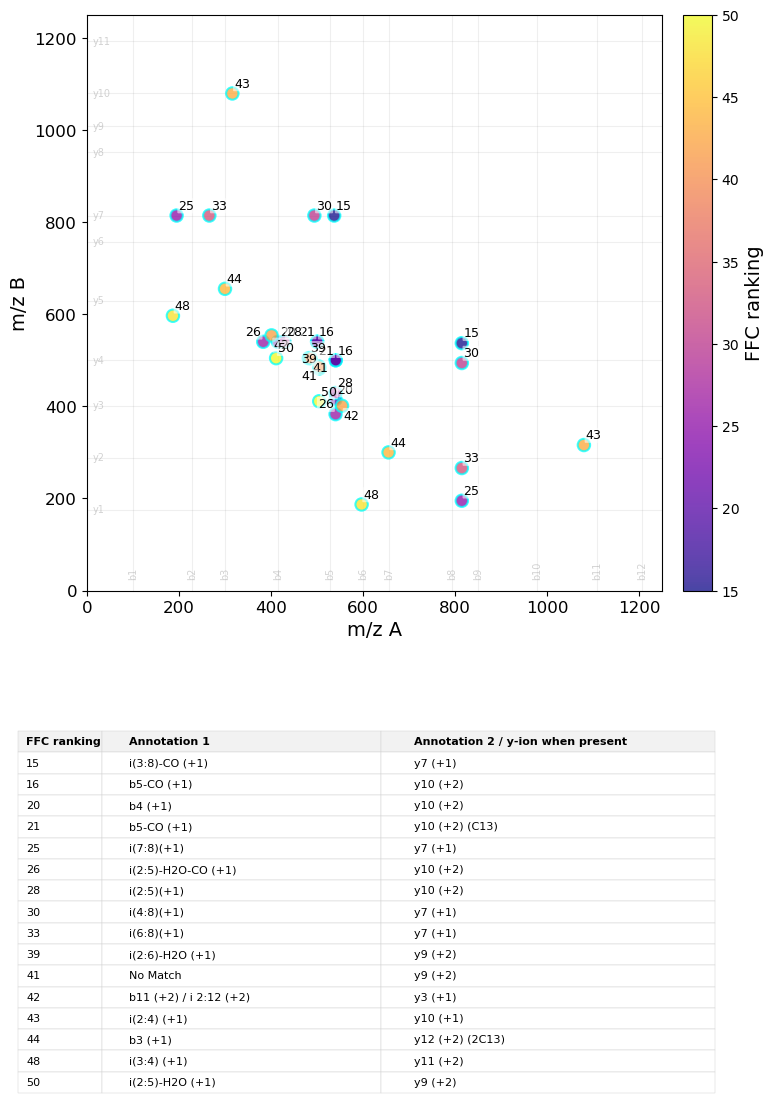

In [845]:
b_ions = {f'b{i}':pep.ion_mass(f'b{i}') for i in range(1, len(PEP_SEQ))}
y_ions = {f'y{i}':pep.ion_mass(f'y{i}') for i in range(1, len(PEP_SEQ))}
ranking_to_drop = [3, 9, 10, 12, 18, 24, 27, 34, 36, 45, 6, 22, 32, 35, 49, 1, 1, 2, 2, 4, 4, 5, 5, 7, 7, 11, 11, 13, 13, 14, 14, 19, 19, 8, 8, 17, 17, 31, 31, 37, 37, 38, 38, 40, 40, 47, 47, 23, 23, 29, 29, 46, 46]
df_annot = df_annot[~df_annot["Ranking"].isin(ranking_to_drop)].copy()


fig, ax, ax_table, annotated_df = plot_ffc_map_with_bottom_annotation_table(
    df_annot,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    ranking_col="Ranking",
    mz_a_anno_col="annotation A",
    mz_b_anno_col="annotation B",
    b_ions=b_ions,
    y_ions=y_ions,
    xlim=(0, 1250),
    ylim=(0, 1250),
    figsize=(9, 14),
    number_fontsize=9,
    table_fontsize=8,
)

In [846]:
df_annot

,Unnamed: 0,m/z A,m/z B,Ranking,annotation A,annotation B
1,613,187.072039,596.845575,48,i(3:4) (+1),y11 (+2)
2,856,195.088350,814.482029,25,i(7:8) (+1),y7 (+1)
3,2248,266.125697,814.482029,33,i(6:8)(+1),y7 (+1)
5,2893,300.156407,655.362039,44,b3 (+1),y12 (+2) (2C13)\t
7,3300,316.114992,1079.601791,43,i(2:4) (+1),y10 (+1)
9,3562,383.194391,540.303260,26,i(2:5)-H2O-CO (+1),y10 (+2)
10,4609,401.288604,554.258768,42,y3 (+1),i(2:12)(+2)
11,4926,411.188975,504.784561,50,i(2:5)-H2O (+1),y9 (+2)
12,5128,415.183883,540.303260,20,b4 (+1),y10 (+2)
17,5824,429.199500,540.303260,28,i(2:5)(+1),y10 (+2)


In [847]:
# Make a copy so the original df_annot is unchanged
df_annot_fixed = df_annot.copy()

# Specify replacements as:
# (row_index, column_name): new_value
no_match_replacements = {
    (19, "annotation A"): "486.221",       # example
    (25, "annotation B"): "486.221"
}

for (idx, col), new_value in no_match_replacements.items():
    df_annot_fixed.loc[idx, col] = new_value

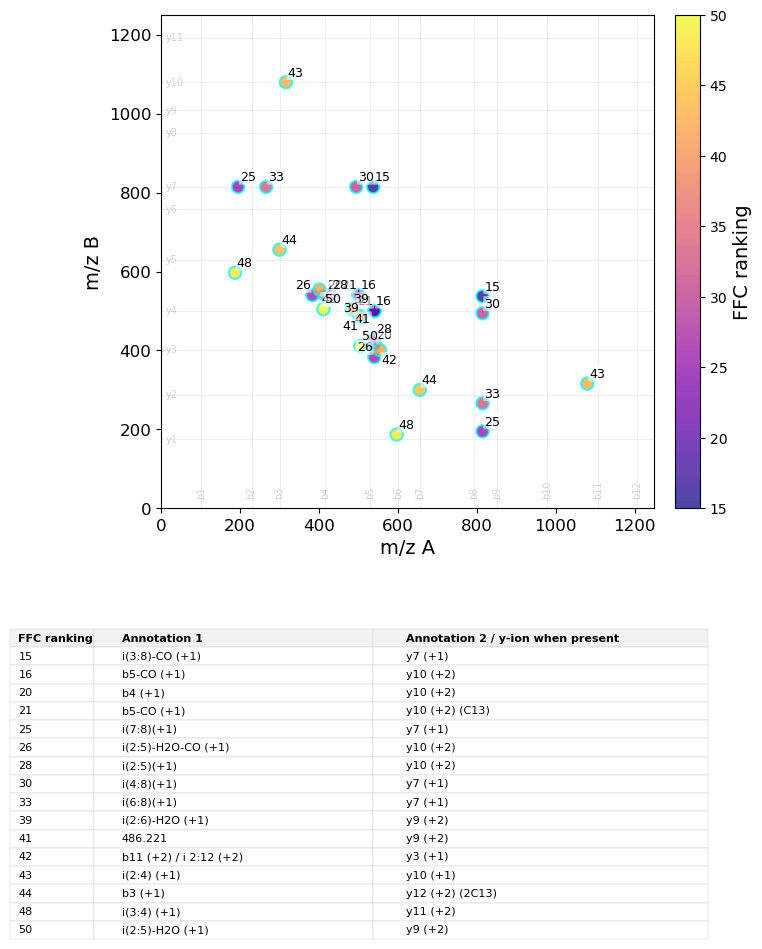

In [848]:
fig, ax, ax_table, annotated_df = plot_ffc_map_with_bottom_annotation_table(
    df_annot_fixed,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    ranking_col="Ranking",
    mz_a_anno_col="annotation A",
    mz_b_anno_col="annotation B",
    b_ions=b_ions,
    y_ions=y_ions,
    xlim=(0, 1250),
    ylim=(0, 1250),
    figsize=(9, 12),
    number_fontsize=9,
    table_fontsize=8,
)

In [872]:
import re
import os
import pandas as pd
import matplotlib.pyplot as plt

try:
    from adjustText import adjust_text
except Exception:  # adjustText optional at import
    adjust_text = None


def _arrange_labels(texts, xs, ys, ax, expand, force_points, force_text, iter_lim):
    """adjustText call that works across old and new API versions."""
    if adjust_text is None or not texts:
        return
    arrow = dict(arrowstyle="-", color="#9aa3ad", lw=0.5)
    try:  # older adjustText API (force_points / iter_lim)
        adjust_text(texts, x=xs, y=ys, ax=ax, arrowprops=arrow,
                    expand=expand, force_points=force_points,
                    force_text=force_text, iter_lim=iter_lim)
    except TypeError:
        try:  # newer adjustText API
            adjust_text(texts, x=xs, y=ys, ax=ax, arrowprops=arrow,
                        expand=expand, force_text=force_text, max_move=None)
        except TypeError:
            adjust_text(texts, x=xs, y=ys, ax=ax, arrowprops=arrow)


def plot_ffc_map_with_bottom_annotation_table_new(
    df,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    ranking_col="ranking",
    mz_a_anno_col="mz_A_annotation",
    mz_b_anno_col="mz_B_annotation",
    b_ions=None,
    y_ions=None,
    xlim=None,
    ylim=None,
    start_from_zero=True,
    figsize=(9, 14),
    plot_height_ratio=5.0,
    table_height_ratio=1.2,
    point_size=80,
    point_alpha=0.85,          # crisp points (was 0.35); each point is labelled
    point_edgecolor="white",   # white halo separates overlaps (was "cyan")
    point_linewidth=0.5,
    cmap="plasma",
    b_ion_color="#2f6690",     # b-ions: muted blue
    y_ion_color="#c0504d",     # y-ions: muted brick-red
    grid_alpha=0.30,           # solid (primary-axis) ladder lines
    dashed_grid_alpha=0.22,    # dashed (complementary-axis) ladder lines
    grid_linewidth=0.8,
    grid_label_alpha=0.75,
    grid_label_fontsize=7,
    show_grid_labels=True,
    background_grid=False,
    force_equal_axis_limits=False,
    equal_aspect=True,
    spine_color="#cfd4d9",
    tick_color="#5a5f66",
    number_fontsize=7,
    number_alpha=1.0,
    table_fontsize=9,
    table_scale_y=1.35,
    max_table_rows=None,
    sort_by_ranking=True,
    table_unique_ranking=True,
    save_path=None,
    # adjustText tuning parameters
    adjust_expand=(1.3, 1.5),
    adjust_force_points=(0.3, 0.3),
    adjust_force_text=(0.5, 0.5),
    adjust_iter_lim=300,
):
    """
    Plot an FFC map with ranking labels on the points and an annotation table below.

    Ion grid (b = blue, y = red), four sides:
      - b-ions: solid vertical   (labels bottom) + dashed horizontal (labels right)
      - y-ions: solid horizontal  (labels left)  + dashed vertical   (labels top)

    Behavior:
    - The plotted points keep both (X, Y) and (Y, X).
    - The bottom table can keep only one row per ranking.
    - The graph starts from (0, 0) by default.
    - Per-point ranking labels are de-overlapped with adjustText.
    """

    def clean_annotation(x):
        if pd.isna(x):
            return ""
        x = str(x).strip()
        x = x.replace("internal", "int")
        return x

    def starts_with_b(anno):
        return bool(re.match(r"^\s*b\d+", anno))

    def starts_with_y(anno):
        return bool(re.match(r"^\s*y\d+", anno))

    def reorder_annotations(anno_a, anno_b):
        """Reorder annotation pair so the y-ion appears second when possible."""
        anno_a = clean_annotation(anno_a)
        anno_b = clean_annotation(anno_b)

        a_is_y = starts_with_y(anno_a)
        b_is_y = starts_with_y(anno_b)
        a_is_b = starts_with_b(anno_a)
        b_is_b = starts_with_b(anno_b)

        if a_is_y and not b_is_y:
            return anno_b, anno_a
        if b_is_y:
            return anno_a, anno_b
        if a_is_b:
            return anno_a, anno_b
        if b_is_b and not a_is_y:
            return anno_b, anno_a
        return anno_a, anno_b

    def format_ranking_value(value):
        if pd.isna(value):
            return ""
        value = float(value)
        if value.is_integer():
            return str(int(value))
        return str(value)

    # ------------------------------------------------------------
    # Clean dataframe
    # ------------------------------------------------------------
    data = df.copy()

    required_cols = [mz_a_col, mz_b_col, ranking_col, mz_a_anno_col, mz_b_anno_col]
    missing_cols = [col for col in required_cols if col not in data.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    data[mz_a_col] = pd.to_numeric(data[mz_a_col], errors="coerce")
    data[mz_b_col] = pd.to_numeric(data[mz_b_col], errors="coerce")
    data[ranking_col] = pd.to_numeric(data[ranking_col], errors="coerce")

    data[mz_a_anno_col] = data[mz_a_anno_col].apply(clean_annotation)
    data[mz_b_anno_col] = data[mz_b_anno_col].apply(clean_annotation)

    before = len(data)
    data = data.dropna(subset=[mz_a_col, mz_b_col, ranking_col])
    after = len(data)
    if before != after:
        print(f"[plot] WARNING: {before - after} row(s) dropped due to NaN. "
              f"Plotting {after} of {before} points.")
    else:
        print(f"[plot] All {after} points will be plotted.")

    if data.empty:
        raise ValueError("No valid data points remain after cleaning the dataframe.")

    # ------------------------------------------------------------
    # Reorder annotation pair for table display only
    # ------------------------------------------------------------
    ordered_pairs = data.apply(
        lambda row: reorder_annotations(row[mz_a_anno_col], row[mz_b_anno_col]),
        axis=1,
    )
    data["annotation_1"] = [p[0] for p in ordered_pairs]
    data["annotation_2"] = [p[1] for p in ordered_pairs]

    if sort_by_ranking:
        data = data.sort_values(ranking_col).reset_index(drop=True)
    else:
        data = data.reset_index(drop=True)

    # ------------------------------------------------------------
    # Determine plot ranges
    # ------------------------------------------------------------
    if xlim is None:
        xlim = (0, data[mz_a_col].max() + 50) if start_from_zero \
            else (data[mz_a_col].min() - 50, data[mz_a_col].max() + 50)
    if ylim is None:
        ylim = (0, data[mz_b_col].max() + 50) if start_from_zero \
            else (data[mz_b_col].min() - 50, data[mz_b_col].max() + 50)

    if force_equal_axis_limits:
        min_limit = min(xlim[0], ylim[0])
        max_limit = max(xlim[1], ylim[1])
        xlim = (min_limit, max_limit)
        ylim = (min_limit, max_limit)

    # ------------------------------------------------------------
    # Layout: plot on top, table below
    # ------------------------------------------------------------
    fig = plt.figure(figsize=figsize)
    fig.patch.set_facecolor("white")
    gs = fig.add_gridspec(
        2, 1, height_ratios=[plot_height_ratio, table_height_ratio], hspace=0.35,
    )
    ax = fig.add_subplot(gs[0, 0])
    ax_table = fig.add_subplot(gs[1, 0])
    ax.set_facecolor("white")
    ax.set_axisbelow(True)

    # ------------------------------------------------------------
    # Four-sided b/y ion grid; all labels OUTSIDE the plot area
    # ------------------------------------------------------------
    x_span = xlim[1] - xlim[0]
    y_span = ylim[1] - ylim[0]
    bottom_label_y = ylim[0] - 0.02 * y_span   # b solid vertical   -> below
    left_label_x   = xlim[0] - 0.01 * x_span   # y solid horizontal -> left
    top_label_y    = ylim[1] + 0.01 * y_span   # y dashed vertical  -> above
    right_label_x  = xlim[1] + 0.012 * x_span  # b dashed horizontal-> right

    if b_ions is not None:
        for ion_name, mz_value in b_ions.items():
            mz_value = float(mz_value)
            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(mz_value, color=b_ion_color, alpha=grid_alpha,
                           linewidth=grid_linewidth, linestyle="-", zorder=0)
                if show_grid_labels:
                    ax.text(mz_value, bottom_label_y, ion_name,
                            color=b_ion_color, alpha=grid_label_alpha,
                            fontsize=grid_label_fontsize, rotation=90,
                            ha="center", va="top", zorder=1, clip_on=False)
            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(mz_value, color=b_ion_color, alpha=dashed_grid_alpha,
                           linewidth=grid_linewidth, linestyle="--", zorder=0)
                if show_grid_labels:
                    ax.text(right_label_x, mz_value, ion_name,
                            color=b_ion_color, alpha=grid_label_alpha,
                            fontsize=grid_label_fontsize,
                            ha="left", va="center", zorder=1, clip_on=False)

    if y_ions is not None:
        for ion_name, mz_value in y_ions.items():
            mz_value = float(mz_value)
            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(mz_value, color=y_ion_color, alpha=grid_alpha,
                           linewidth=grid_linewidth, linestyle="-", zorder=0)
                if show_grid_labels:
                    ax.text(left_label_x, mz_value, ion_name,
                            color=y_ion_color, alpha=grid_label_alpha,
                            fontsize=grid_label_fontsize,
                            ha="right", va="center", zorder=1, clip_on=False)
            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(mz_value, color=y_ion_color, alpha=dashed_grid_alpha,
                           linewidth=grid_linewidth, linestyle="--", zorder=0)
                if show_grid_labels:
                    ax.text(mz_value, top_label_y, ion_name,
                            color=y_ion_color, alpha=grid_label_alpha,
                            fontsize=grid_label_fontsize, rotation=90,
                            ha="center", va="bottom", zorder=1, clip_on=False)

    # ------------------------------------------------------------
    # Scatter coloured by ranking
    # ------------------------------------------------------------
    scatter = ax.scatter(
        data[mz_a_col], data[mz_b_col],
        c=data[ranking_col], cmap=cmap, s=point_size,
        edgecolors=point_edgecolor, linewidths=point_linewidth,
        alpha=point_alpha, zorder=3,
    )

    cbar = fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.10)
    cbar.set_label("FFC ranking", fontsize=13, color="#2b2f33")
    cbar.outline.set_edgecolor(spine_color)
    cbar.ax.tick_params(labelsize=10, colors=tick_color)

    # ------------------------------------------------------------
    # Per-point ranking labels (arranged with adjustText)
    # ------------------------------------------------------------
    texts = []
    for _, row in data.iterrows():
        t = ax.text(
            row[mz_a_col], row[mz_b_col], format_ranking_value(row[ranking_col]),
            fontsize=number_fontsize, alpha=number_alpha, color="#1b1f23",
            fontweight="bold", ha="center", va="center", zorder=5,
            bbox=dict(boxstyle="round,pad=0.18", fc="white",
                      ec="#b9bfc6", alpha=0.88, lw=0.5),
        )
        texts.append(t)

    _arrange_labels(
        texts, data[mz_a_col].values, data[mz_b_col].values, ax,
        adjust_expand, adjust_force_points, adjust_force_text, adjust_iter_lim,
    )

    # ------------------------------------------------------------
    # Axis formatting
    # ------------------------------------------------------------
    ax.set_xlabel("m/z A", fontsize=14, labelpad=18, color="#2b2f33")
    ax.set_ylabel("m/z B", fontsize=14, labelpad=18, color="#2b2f33")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    if equal_aspect:
        ax.set_aspect("equal", adjustable="box")
    for spine in ax.spines.values():
        spine.set_color(spine_color)
        spine.set_linewidth(0.9)
    ax.tick_params(axis="x", labelsize=12, pad=22, colors=tick_color)
    ax.tick_params(axis="y", labelsize=12, pad=22, colors=tick_color)

    if background_grid:
        ax.grid(True, alpha=0.12, linewidth=0.5)

    # ------------------------------------------------------------
    # Bottom annotation table (unchanged logic)
    # ------------------------------------------------------------
    ax_table.axis("off")

    table_data = data.copy()
    if table_unique_ranking:
        table_data = (
            table_data.sort_values(ranking_col)
            .drop_duplicates(subset=[ranking_col], keep="first")
            .reset_index(drop=True)
        )
    if max_table_rows is not None:
        table_data = table_data.head(max_table_rows)

    table_rows = []
    for _, row in table_data.iterrows():
        table_rows.append([
            format_ranking_value(row[ranking_col]),
            f"{row[mz_a_col]:.3f}",
            row["annotation_1"],
            f"{row[mz_b_col]:.3f}",
            row["annotation_2"],
        ])

    col_labels = ["Ranking", "m/z X", "Annotation A", "m/z Y", "Annotation B"]

    table = ax_table.table(
        cellText=table_rows, colLabels=col_labels,
        cellLoc="center", colLoc="center", loc="center",
        colWidths=[0.08, 0.12, 0.30, 0.12, 0.30],
        bbox=[0, 0, 1, 1],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(table_fontsize)
    table.scale(1.0, table_scale_y)

    for (row_idx, col_idx), cell in table.get_celld().items():
        cell.set_edgecolor("lightgray")
        cell.set_linewidth(0.35)
        if row_idx == 0:
            cell.set_facecolor("#34699a")
            cell.set_text_props(weight="bold", color="white")
        elif row_idx % 2 == 1:
            cell.set_facecolor("#e7edf5")
        else:
            cell.set_facecolor("white")
        if col_idx in (1, 3) and row_idx > 0:
            cell.get_text().set_ha("right")

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return fig, ax, ax_table, data


[plot] All 32 points will be plotted.


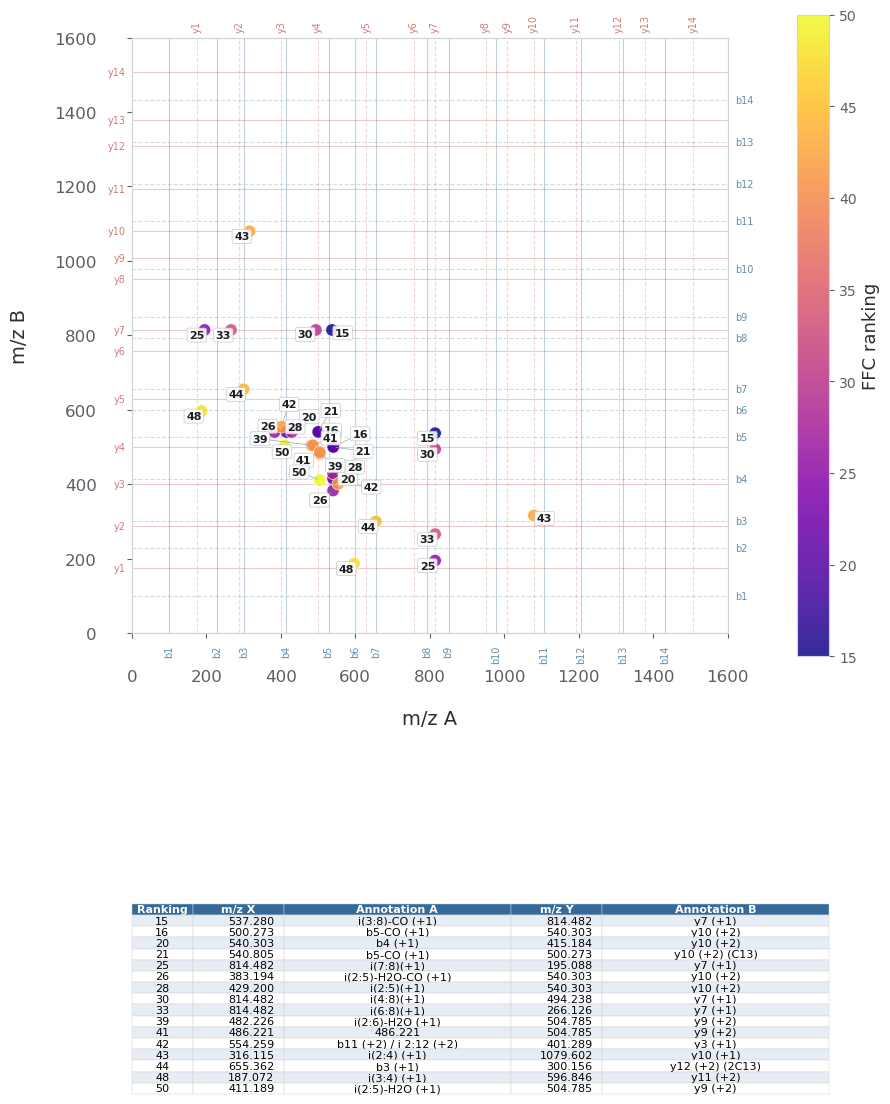

In [876]:
df_annot = pd.read_csv('point_not_line_VEA.csv')
df_annot.head()

df_annot = df_annot[~df_annot["Ranking"].isin(ranking_to_drop)].copy()
df_annot_fixed = df_annot.copy()

# Specify replacements as:
# (row_index, column_name): new_value
no_match_replacements = {
    (19, "annotation A"): "486.221",       # example
    (25, "annotation B"): "486.221"
}

for (idx, col), new_value in no_match_replacements.items():
    df_annot_fixed.loc[idx, col] = new_value

fig, ax, ax_table, annotated_df = plot_ffc_map_with_bottom_annotation_table_new(
    df_annot_fixed,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    ranking_col="Ranking",
    mz_a_anno_col="annotation A",
    mz_b_anno_col="annotation B",
    b_ions=b_ions,
    y_ions=y_ions,
    xlim=(0, 1600),
    ylim=(0, 1600),
    figsize=(9, 15),
    number_fontsize=8,
    table_fontsize=8,
)

In [851]:
df_annot_fixed.head()

,Unnamed: 0,m/z A,m/z B,Ranking,annotation A,annotation B
1,613,187.072039,596.845575,48,i(3:4) (+1),y11 (+2)
2,856,195.088350,814.482029,25,i(7:8) (+1),y7 (+1)
3,2248,266.125697,814.482029,33,i(6:8)(+1),y7 (+1)
5,2893,300.156407,655.362039,44,b3 (+1),y12 (+2) (2C13)\t
7,3300,316.114992,1079.601791,43,i(2:4) (+1),y10 (+1)


In [852]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text


def plot_ffc_map_with_bottom_annotation_table(
    df,
    mz_a_col="mz_A",
    mz_b_col="mz_B",
    ranking_col="ranking",
    mz_a_anno_col="mz_A_annotation",
    mz_b_anno_col="mz_B_annotation",
    b_ions=None,
    y_ions=None,
    xlim=None,
    ylim=None,
    start_from_zero=True,
    figsize=(9, 14),
    plot_height_ratio=5.0,
    table_height_ratio=1.2,
    point_size=80,
    point_alpha=0.35,          # transparent so overlapping points visually stack
    point_edgecolor="cyan",
    point_linewidth=0.8,       # thinner edge for cleaner look at low alpha
    cmap="plasma",
    grid_alpha=0.12,
    grid_linewidth=0.8,
    grid_label_alpha=0.35,
    grid_label_fontsize=7,
    show_grid_labels=True,
    background_grid=False,
    force_equal_axis_limits=False,
    number_fontsize=7,
    number_alpha=1.0,
    table_fontsize=9,
    table_scale_y=1.35,
    max_table_rows=None,
    sort_by_ranking=True,
    table_unique_ranking=True,
    save_path=None,
    # adjustText tuning parameters
    adjust_expand=(1.3, 1.5),
    adjust_force_points=(0.3, 0.3),
    adjust_force_text=(0.5, 0.5),
    adjust_iter_lim=300,
):
    """
    Plot an FFC map with ranking labels on the points and an annotation table below.

    Important behavior:
    - The plotted points keep both (X, Y) and (Y, X).
    - The bottom table can keep only one row per ranking.
    - The graph starts from (0, 0) by default.
    - Only b-ion vertical lines are drawn on the x-axis.
    - Only y-ion horizontal lines are drawn on the y-axis.
    - Points are transparent (alpha=0.35) so overlaps are visually apparent.
    - Labels are positioned using adjustText for automatic collision avoidance.
    """

    def clean_annotation(x):
        if pd.isna(x):
            return ""
        x = str(x).strip()
        # Convert "int X:Y..." or "internal X:Y..." to "i(X:Y)..."
        # e.g. "int 2:5-H2O-CO (+1)" -> "i(2:5)-H2O-CO (+1)"
        #      "internal 3:8 (+1) (C13)" -> "i(3:8) (+1) (C13)"
        x = re.sub(
            r"\b(?:internal|int)\s+(\d+[:\-]\d+)",
            r"i(\1)",
            x,
        )
        return x

    def starts_with_b(anno):
        return bool(re.match(r"^\s*b\d+", anno))

    def starts_with_y(anno):
        return bool(re.match(r"^\s*y\d+", anno))

    def reorder_annotations(anno_a, anno_b):
        """
        Reorder annotation pair so that the y-ion appears second when possible.
        """
        anno_a = clean_annotation(anno_a)
        anno_b = clean_annotation(anno_b)

        a_is_y = starts_with_y(anno_a)
        b_is_y = starts_with_y(anno_b)
        a_is_b = starts_with_b(anno_a)
        b_is_b = starts_with_b(anno_b)

        if a_is_y and not b_is_y:
            return anno_b, anno_a
        if b_is_y:
            return anno_a, anno_b
        if a_is_b:
            return anno_a, anno_b
        if b_is_b and not a_is_y:
            return anno_b, anno_a
        return anno_a, anno_b

    def format_ranking_value(value):
        if pd.isna(value):
            return ""
        value = float(value)
        if value.is_integer():
            return str(int(value))
        return str(value)

    # ------------------------------------------------------------
    # Clean dataframe
    # ------------------------------------------------------------

    data = df.copy()

    required_cols = [
        mz_a_col,
        mz_b_col,
        ranking_col,
        mz_a_anno_col,
        mz_b_anno_col,
    ]

    missing_cols = [col for col in required_cols if col not in data.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    data[mz_a_col] = pd.to_numeric(data[mz_a_col], errors="coerce")
    data[mz_b_col] = pd.to_numeric(data[mz_b_col], errors="coerce")
    data[ranking_col] = pd.to_numeric(data[ranking_col], errors="coerce")

    data[mz_a_anno_col] = data[mz_a_anno_col].apply(clean_annotation)
    data[mz_b_anno_col] = data[mz_b_anno_col].apply(clean_annotation)

    before = len(data)
    data = data.dropna(subset=[mz_a_col, mz_b_col, ranking_col])
    after = len(data)

    if before != after:
        print(f"[plot] WARNING: {before - after} row(s) dropped due to NaN. "
              f"Plotting {after} of {before} points.")
    else:
        print(f"[plot] All {after} points will be plotted.")

    if data.empty:
        raise ValueError("No valid data points remain after cleaning the dataframe.")

    # ------------------------------------------------------------
    # Reorder annotation pair for table display only
    # ------------------------------------------------------------

    ordered_pairs = data.apply(
        lambda row: reorder_annotations(
            row[mz_a_anno_col],
            row[mz_b_anno_col],
        ),
        axis=1,
    )

    data["annotation_1"] = [p[0] for p in ordered_pairs]
    data["annotation_2"] = [p[1] for p in ordered_pairs]

    if sort_by_ranking:
        data = data.sort_values(ranking_col).reset_index(drop=True)
    else:
        data = data.reset_index(drop=True)

    # ------------------------------------------------------------
    # Determine plot ranges
    # ------------------------------------------------------------

    if xlim is None:
        if start_from_zero:
            xlim = (0, data[mz_a_col].max() + 50)
        else:
            xlim = (data[mz_a_col].min() - 50, data[mz_a_col].max() + 50)

    if ylim is None:
        if start_from_zero:
            ylim = (0, data[mz_b_col].max() + 50)
        else:
            ylim = (data[mz_b_col].min() - 50, data[mz_b_col].max() + 50)

    if force_equal_axis_limits:
        min_limit = min(xlim[0], ylim[0])
        max_limit = max(xlim[1], ylim[1])
        xlim = (min_limit, max_limit)
        ylim = (min_limit, max_limit)

    # ------------------------------------------------------------
    # Create layout: plot on top, table below
    # ------------------------------------------------------------

    fig = plt.figure(figsize=figsize)

    gs = fig.add_gridspec(
        2,
        1,
        height_ratios=[plot_height_ratio, table_height_ratio],
        hspace=0.30,
    )

    ax = fig.add_subplot(gs[0, 0])
    ax_table = fig.add_subplot(gs[1, 0])

    # ------------------------------------------------------------
    # Add b/y ion grid lines
    # ------------------------------------------------------------

    b_label_y = ylim[0] + 0.02 * (ylim[1] - ylim[0])
    y_label_x = xlim[0] + 0.01 * (xlim[1] - xlim[0])

    if b_ions is not None:
        for ion_name, mz_value in b_ions.items():
            mz_value = float(mz_value)
            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(
                    x=mz_value, color="gray", alpha=grid_alpha,
                    linewidth=grid_linewidth, zorder=0,
                )
                if show_grid_labels:
                    ax.text(
                        mz_value, b_label_y, ion_name,
                        color="gray", alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize, rotation=90,
                        ha="center", va="bottom", zorder=1,
                    )

    if y_ions is not None:
        for ion_name, mz_value in y_ions.items():
            mz_value = float(mz_value)
            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(
                    y=mz_value, color="gray", alpha=grid_alpha,
                    linewidth=grid_linewidth, zorder=0,
                )
                if show_grid_labels:
                    ax.text(
                        y_label_x, mz_value, ion_name,
                        color="gray", alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        ha="left", va="center", zorder=1,
                    )

    # ------------------------------------------------------------
    # Scatter plot — transparent so overlapping points stack visually
    # ------------------------------------------------------------

    scatter = ax.scatter(
        data[mz_a_col],
        data[mz_b_col],
        c=data[ranking_col],
        cmap=cmap,
        s=point_size,
        edgecolors=point_edgecolor,
        linewidths=point_linewidth,
        alpha=point_alpha,
        zorder=3,
    )

    cbar = fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label("FFC ranking", fontsize=14)

    # ------------------------------------------------------------
    # Ranking labels — adjustText-based repulsion for no overlaps
    # ------------------------------------------------------------

    texts = []
    for _, row in data.iterrows():
        t = ax.text(
            row[mz_a_col],
            row[mz_b_col],
            format_ranking_value(row[ranking_col]),
            fontsize=number_fontsize,
            alpha=number_alpha,
            color="black",
            fontweight="bold",
            ha="center",
            va="center",
            zorder=5,
            bbox=dict(
                boxstyle="round,pad=0.18",
                fc="white",
                ec="gray",
                alpha=0.75,
                lw=0.5,
            ),
        )
        texts.append(t)

    adjust_text(
        texts,
        x=data[mz_a_col].values,
        y=data[mz_b_col].values,
        ax=ax,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
        expand=adjust_expand,
        force_points=adjust_force_points,
        force_text=adjust_force_text,
        iter_lim=adjust_iter_lim,
    )

    # ------------------------------------------------------------
    # Axis formatting
    # ------------------------------------------------------------

    ax.set_xlabel("m/z A", fontsize=14)
    ax.set_ylabel("m/z B", fontsize=14)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.tick_params(axis="both", labelsize=12)

    if background_grid:
        ax.grid(True, alpha=0.12, linewidth=0.5)

    # ------------------------------------------------------------
    # Bottom annotation table
    # Table only: keep one row per ranking.
    # Plot still keeps all points.
    # ------------------------------------------------------------

    ax_table.axis("off")

    table_data = data.copy()

    if table_unique_ranking:
        table_data = (
            table_data
            .sort_values(ranking_col)
            .drop_duplicates(subset=[ranking_col], keep="first")
            .reset_index(drop=True)
        )

    if max_table_rows is not None:
        table_data = table_data.head(max_table_rows)

    table_rows = []
    for _, row in table_data.iterrows():
        ffc_xy = f"{row[mz_a_col]:.3f}, {row[mz_b_col]:.3f}"
        table_rows.append([
            format_ranking_value(row[ranking_col]),
            ffc_xy,
            row["annotation_1"],
            row["annotation_2"],
        ])

    col_labels = [
        "Ranking",
        "FFC(X, Y)",
        "Annotation X",
        "Annotation Y",
    ]

    table = ax_table.table(
        cellText=table_rows,
        colLabels=col_labels,
        cellLoc="left",
        colLoc="left",
        loc="center",
        colWidths=[0.10, 0.22, 0.34, 0.34],
        bbox=[0, 0, 1, 1],
    )

    table.auto_set_font_size(False)
    table.set_fontsize(table_fontsize)
    table.scale(1.0, table_scale_y)

    for (row_idx, col_idx), cell in table.get_celld().items():
        cell.set_edgecolor("lightgray")
        cell.set_linewidth(0.35)
        # Left-align everything
        cell.get_text().set_ha("left")

        if row_idx == 0:
            # Header row
            cell.set_facecolor("#4472C4")
            cell.set_text_props(weight="bold", color="white")
        elif row_idx % 2 == 1:
            cell.set_facecolor("#D9E2F3")
        else:
            cell.set_facecolor("white")

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return fig, ax, ax_table, data

[plot] All 32 points will be plotted.


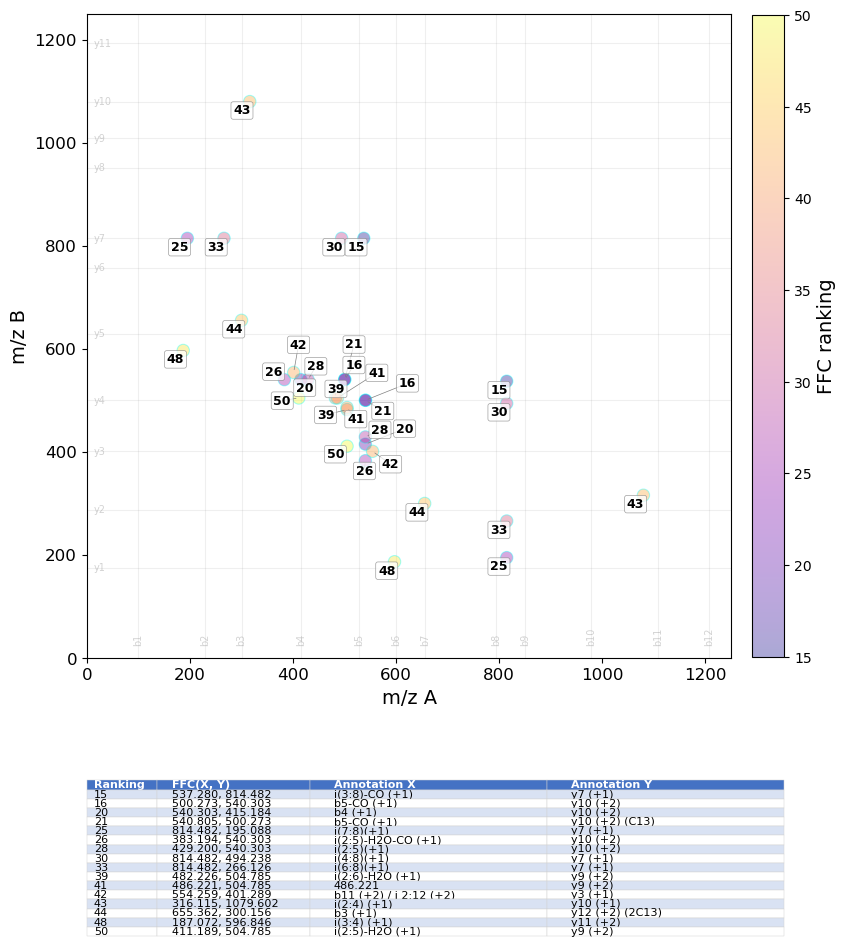

In [853]:
fig, ax, ax_table, annotated_df = plot_ffc_map_with_bottom_annotation_table(
    df_annot_fixed,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    ranking_col="Ranking",
    mz_a_anno_col="annotation A",
    mz_b_anno_col="annotation B",
    b_ions=b_ions,
    y_ions=y_ions,
    xlim=(0, 1250),
    ylim=(0, 1250),
    figsize=(9, 12),
    number_fontsize=9,
    table_fontsize=8,
)

In [854]:
tffc_table = pd.read_excel('/Users/kevinmbp/Desktop/2D_spec_dict/paper/VEA_annot_with_charges.xlsx')

In [855]:
tffc_table['tffc_A'] = (tffc_table['m/z A'] - 1.0072) * tffc_table['charge A']
tffc_table['tffc_B'] = (tffc_table['m/z B'] - 1.0072) * tffc_table['charge B']


In [856]:
tffc_table.head()

,Ranking,m/z A,Interpretation A,error A,m/z B,Interpretation B,error B,charge A,charge B,tffc_A,tffc_B
0,1,1204.639,internal 3:14 (+1),-0.007,175.120,y1 (+1),-0.001,1.0,1,1203.6318,174.1128
1,2,565.275,internal 3:8 (+1),-0.002,814.482,y7 (+1),-0.004,1.0,1,564.2678,813.4748
2,3,300.156,b3 (+1),-0.001,654.359,y12 (+2),-0.002,1.0,2,299.1488,1306.7036
3,4,879.400,internal 3:11 (+1),-0.004,500.357,y4 (+1),-0.002,1.0,1,878.3928,499.3498
4,5,750.357,internal 3:10 (+1),-0.004,629.401,y5 (+1),-0.003,1.0,1,749.3498,628.3938


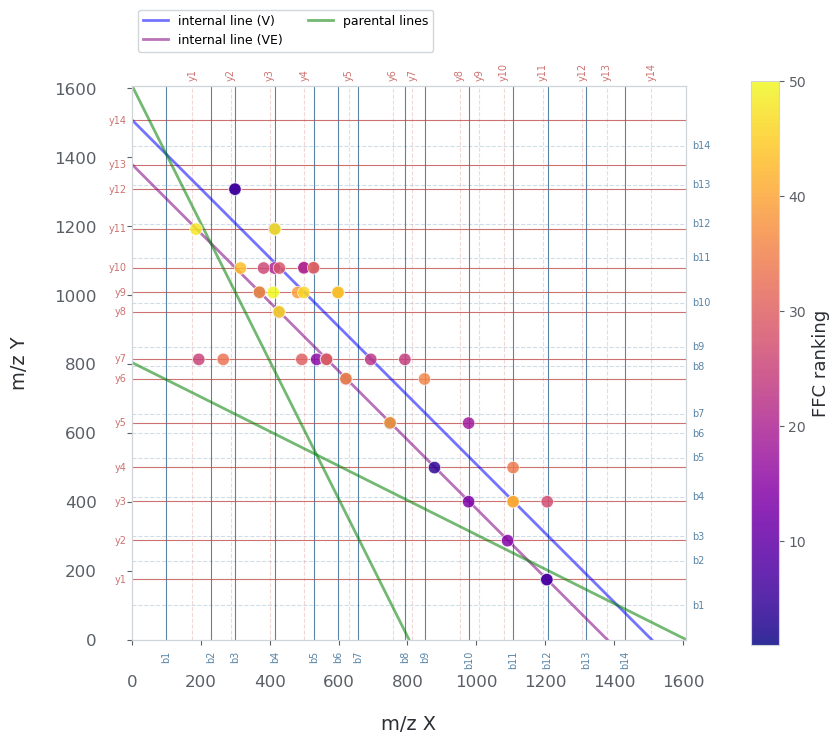

(<Figure size 850x750 with 2 Axes>, <Axes: xlabel='m/z X', ylabel='m/z Y'>)

In [857]:
plot_ffc_map(
    tffc_table,
    mz_a_col="tffc_A",
    mz_b_col="tffc_B",
    ranking_col="Ranking",
    lines=exact_lines,
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    grid_alpha=0.8,
    grid_label_alpha=0.8,
    grid_label_fontsize=7
)

In [858]:
# Suppose your original table is called tffc_table

df = tffc_table.copy()

# Create the swapped version

swapped = df.copy()

# Swap A-side and B-side columns

swap_pairs = [

    ("m/z A", "m/z B"),

    ("Interpretation A", "Interpretation B"),

    ("error A", "error B"),

    ("charge A", "charge B"),

    ("tffc_A", "tffc_B"),

]

for col_a, col_b in swap_pairs:

    swapped[col_a], swapped[col_b] = df[col_b], df[col_a]

# Concatenate original + swapped

tffc_table_doubled = pd.concat([df, swapped], ignore_index=True)

# Optional: reset Ranking from 1 to length

#tffc_table_doubled["Ranking"] = range(1, len(tffc_table_doubled) + 1)

tffc_table_doubled

,Ranking,m/z A,Interpretation A,error A,m/z B,Interpretation B,error B,charge A,charge B,tffc_A,tffc_B
0,1,1204.639,internal 3:14 (+1),-0.007,175.120,y1 (+1),-0.001,1.0,1.0,1203.6318,174.1128
1,2,565.275,internal 3:8 (+1),-0.002,814.482,y7 (+1),-0.004,1.0,1.0,564.2678,813.4748
2,3,300.156,b3 (+1),-0.001,654.359,y12 (+2),-0.002,1.0,2.0,299.1488,1306.7036
3,4,879.400,internal 3:11 (+1),-0.004,500.357,y4 (+1),-0.002,1.0,1.0,878.3928,499.3498
4,5,750.357,internal 3:10 (+1),-0.004,629.401,y5 (+1),-0.003,1.0,1.0,749.3498,628.3938
...,...,...,...,...,...,...,...,...,...,...,...
95,46,1008.564,y9 (+1),-0.005,500.237,internal 2:6 (+1),-0.002,1.0,1.0,1007.5568,499.2298
96,47,952.545,y8 (+1) (C13),-0.004,428.216,internal 3:7 (+1),-0.002,1.0,1.0,951.5378,427.2088
97,48,596.846,y11 (+2),-0.002,187.072,internal 3:4 (+1),-0.001,2.0,1.0,1191.6776,186.0648
98,49,596.846,y11 (+2),-0.002,416.187,b4 (+1) (C13),-0.001,2.0,1.0,1191.6776,415.1798


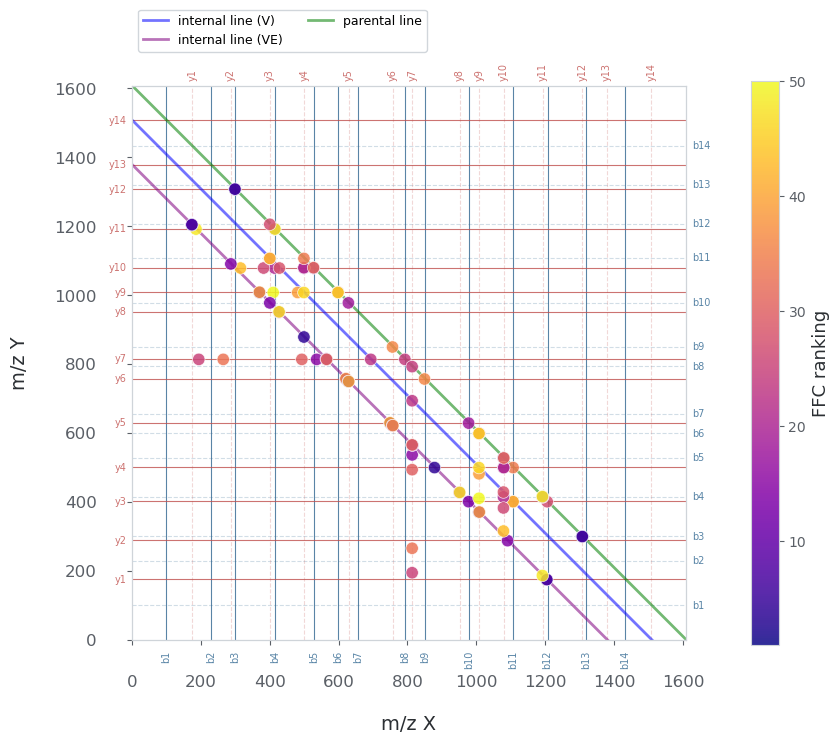

(<Figure size 850x750 with 2 Axes>, <Axes: xlabel='m/z X', ylabel='m/z Y'>)

In [859]:
exact_lines = [
    {"slope": -1, "intercept": 1608.869-100.069, "color": "blue", "label": "internal line (V)"},
    {"slope": -1, "intercept": 1608.869 - 229.112, "color": "purple", "label": "internal line (VE)"},
    {"slope": -1, "intercept": 1608.869, "color": "green", "label": "parental line"},
]


plot_ffc_map(
    tffc_table_doubled,
    mz_a_col="tffc_A",
    mz_b_col="tffc_B",
    ranking_col="Ranking",
    lines=exact_lines,
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    grid_alpha=0.8,
    grid_label_alpha=0.8,
    grid_label_fontsize=7
)

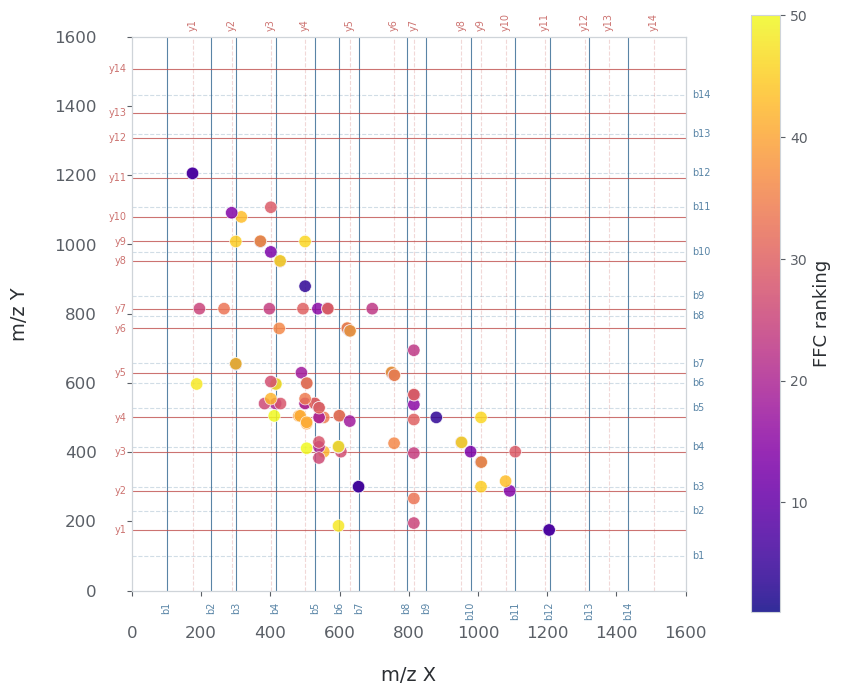

(<Figure size 850x750 with 2 Axes>, <Axes: xlabel='m/z X', ylabel='m/z Y'>)

In [860]:

plot_ffc_map(
    tffc_table_doubled,
    mz_a_col="m/z A",
    mz_b_col="m/z B",
    ranking_col="Ranking",
    lines=None,
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    grid_alpha=0.8,
    grid_label_alpha=0.8,
    grid_label_fontsize=7,
    xlim = (0, 1600),
    ylim = (0, 1600)
)

In [861]:
tffc_table['tffc_A1'] = (tffc_table['m/z A']) * tffc_table['charge A']
tffc_table['tffc_B1'] = (tffc_table['m/z B']) * tffc_table['charge B']



In [862]:
tffc_table[['m/z A', 'm/z B']]

,m/z A,m/z B
0,1204.639,175.120
1,565.275,814.482
2,300.156,654.359
3,879.400,500.357
4,750.357,629.401
5,300.156,654.861
6,371.194,1008.564
7,1205.642,175.120
8,415.184,596.846
9,599.306,504.785


In [863]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_ffc_map_full_grid(
    df,
    mz_a_col="mz_A",
    mz_b_col="mz_B",
    ranking_col="ranking",
    lines=None,
    b_ions=None,
    y_ions=None,
    xlim=None,
    ylim=None,
    start_from_zero=True,
    figsize=(8, 7),
    point_size=80,
    line_alpha=0.45,
    grid_alpha=0.12,
    grid_linewidth=0.8,
    grid_label_alpha=0.45,
    grid_label_fontsize=7,
    show_grid_labels=True,
    dashed_grid_color="cornflowerblue",   # distinct color for dashed lines + labels
    dashed_grid_alpha=0.70,               # higher alpha so dashed lines are visible
):
    """
    Plot an FFC map with full b/y ion grids on all four sides:

      - b-ions: solid vertical lines (labels at bottom)
                dashed horizontal lines (labels at right)
      - y-ions: solid horizontal lines (labels at left)
                dashed vertical lines (labels at top)

    If lines=None, no diagonal/charge lines will be drawn.
    """

    data = df.copy()

    # Convert columns to numeric values
    data[mz_a_col] = pd.to_numeric(data[mz_a_col], errors="coerce")
    data[mz_b_col] = pd.to_numeric(data[mz_b_col], errors="coerce")
    data[ranking_col] = pd.to_numeric(data[ranking_col], errors="coerce")

    # Remove invalid rows
    data = data.dropna(subset=[mz_a_col, mz_b_col, ranking_col])

    if data.empty:
        raise ValueError("No valid data points remain after cleaning the dataframe.")

    # Determine plot ranges
    if xlim is None:
        if start_from_zero:
            xlim = (0, data[mz_a_col].max() + 300)
        else:
            xlim = (data[mz_a_col].min() - 50, data[mz_a_col].max() + 300)

    if ylim is None:
        if start_from_zero:
            ylim = (0, data[mz_b_col].max() + 300)
        else:
            ylim = (data[mz_b_col].min() - 50, data[mz_b_col].max() + 300)

    fig, ax = plt.subplots(figsize=figsize)

    # ------------------------------------------------------------
    # Label offsets — all labels sit OUTSIDE the plot area
    # ------------------------------------------------------------

    x_offset = 0.005 * (xlim[1] - xlim[0])
    y_offset = 0.005 * (ylim[1] - ylim[0])

    # b-ion solid vertical → labels below x-axis
    bottom_label_y = ylim[0] - 0.02 * (ylim[1] - ylim[0])
    # y-ion solid horizontal → labels left of y-axis
    left_label_x   = xlim[0] - 0.01 * (xlim[1] - xlim[0])
    # y-ion dashed vertical → labels above top edge
    top_label_y    = ylim[1] + 0.01 * (ylim[1] - ylim[0])
    # b-ion dashed horizontal → labels right of right edge
    right_label_x  = xlim[1] + 0.01 * (xlim[1] - xlim[0])

    # ------------------------------------------------------------
    # b-ions: solid vertical (bottom) + dashed horizontal (right)
    # ------------------------------------------------------------

    if b_ions is not None:
        for ion_name, mz_value in b_ions.items():
            mz_value = float(mz_value)

            # Solid vertical line (x-axis), label below
            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(
                    x=mz_value, color="gray", alpha=grid_alpha,
                    linewidth=grid_linewidth, linestyle="-", zorder=0,
                )
                if show_grid_labels:
                    ax.text(
                        mz_value, bottom_label_y, ion_name,
                        color="gray", alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize, rotation=90,
                        ha="center", va="top", zorder=1,
                        clip_on=False,
                    )

            # Dashed horizontal line (y-axis), label at right outside
            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(
                    y=mz_value, color=dashed_grid_color, alpha=dashed_grid_alpha,
                    linewidth=grid_linewidth, linestyle="--", zorder=0,
                )
                if show_grid_labels:
                    ax.text(
                        right_label_x, mz_value, ion_name,
                        color=dashed_grid_color, alpha=dashed_grid_alpha,
                        fontsize=grid_label_fontsize,
                        ha="left", va="center", zorder=1,
                        clip_on=False,
                    )

    # ------------------------------------------------------------
    # y-ions: solid horizontal (left) + dashed vertical (top)
    # ------------------------------------------------------------

    if y_ions is not None:
        for ion_name, mz_value in y_ions.items():
            mz_value = float(mz_value)

            # Solid horizontal line (y-axis), label at left outside
            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(
                    y=mz_value, color="gray", alpha=grid_alpha,
                    linewidth=grid_linewidth, linestyle="-", zorder=0,
                )
                if show_grid_labels:
                    ax.text(
                        left_label_x, mz_value, ion_name,
                        color="gray", alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        ha="right", va="center", zorder=1,
                        clip_on=False,
                    )

            # Dashed vertical line (x-axis), label at top outside
            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(
                    x=mz_value, color=dashed_grid_color, alpha=dashed_grid_alpha,
                    linewidth=grid_linewidth, linestyle="--", zorder=0,
                )
                if show_grid_labels:
                    ax.text(
                        mz_value, top_label_y, ion_name,
                        color=dashed_grid_color, alpha=dashed_grid_alpha,
                        fontsize=grid_label_fontsize, rotation=90,
                        ha="center", va="bottom", zorder=1,
                        clip_on=False,
                    )

    # ------------------------------------------------------------
    # Scatter plot
    # ------------------------------------------------------------

    scatter = ax.scatter(
        data[mz_a_col],
        data[mz_b_col],
        c=data[ranking_col],
        cmap="plasma",
        s=point_size,
        edgecolors="cyan",
        linewidths=1.5,
        alpha=0.75,
        zorder=3
    )

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("FFC ranking", fontsize=14)

    # ------------------------------------------------------------
    # Draw main diagonal/charge lines only if provided
    # ------------------------------------------------------------

    if lines is not None:
        x_values = np.linspace(xlim[0], xlim[1], 500)

        for line in lines:
            slope = line.get("slope")
            intercept = line.get("intercept")
            color = line.get("color", "black")
            label = line.get("label", None)

            y_values = slope * x_values + intercept

            ax.plot(
                x_values,
                y_values,
                color=color,
                alpha=line_alpha,
                linewidth=2,
                label=label,
                zorder=2
            )

        if any(line.get("label") is not None for line in lines):
            ax.legend(
                loc="lower left",
                bbox_to_anchor=(0.0, 1.08),
                fontsize=10,
                framealpha=0.9,
                ncol=2,
            )

    # ------------------------------------------------------------
    # Axis labels and formatting
    # ------------------------------------------------------------

    ax.set_xlabel("m/z A", fontsize=14, labelpad=20)
    ax.set_ylabel("m/z B", fontsize=14, labelpad=20)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.tick_params(axis="x", labelsize=12, pad=23)
    ax.tick_params(axis="y", labelsize=12, pad=23)

    plt.tight_layout()
    plt.subplots_adjust(left=0.15, right=0.88, top=0.85, bottom=0.15)
    plt.show()

    return fig, ax

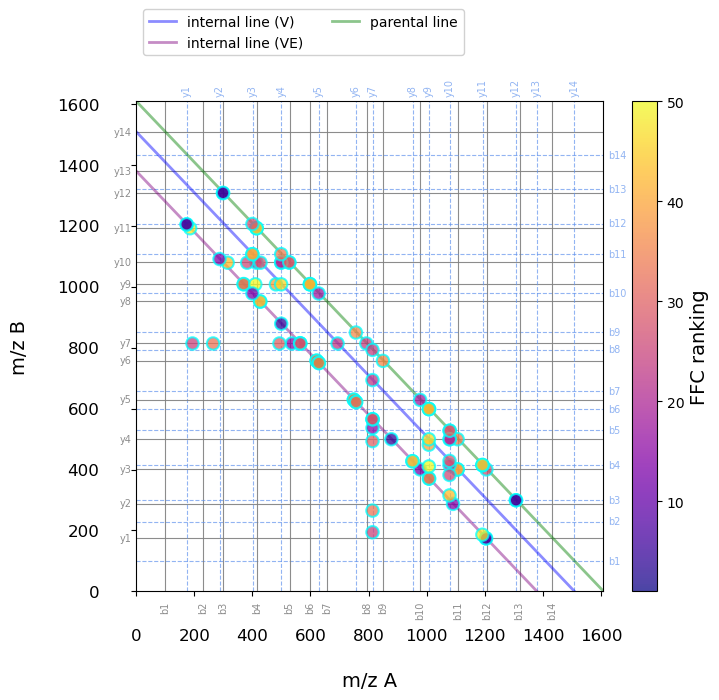

(<Figure size 800x700 with 2 Axes>, <Axes: xlabel='m/z A', ylabel='m/z B'>)

In [864]:
plot_ffc_map_full_grid(
    tffc_table_doubled,
    mz_a_col="tffc_A",
    mz_b_col="tffc_B",
    ranking_col="Ranking",
    lines=exact_lines,
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    grid_alpha=0.9,
    grid_label_alpha=0.9,
    grid_label_fontsize=7
)

In [865]:
ranking_to_keep = [3, 9, 12, 10, 24, 36, 18, 34, 61, 7, 19, 2, 11, 5, 4, 13, 14, 1] 
df_parent_tfcc = tffc_table_doubled[tffc_table_doubled["Ranking"].isin(ranking_to_keep)].copy()

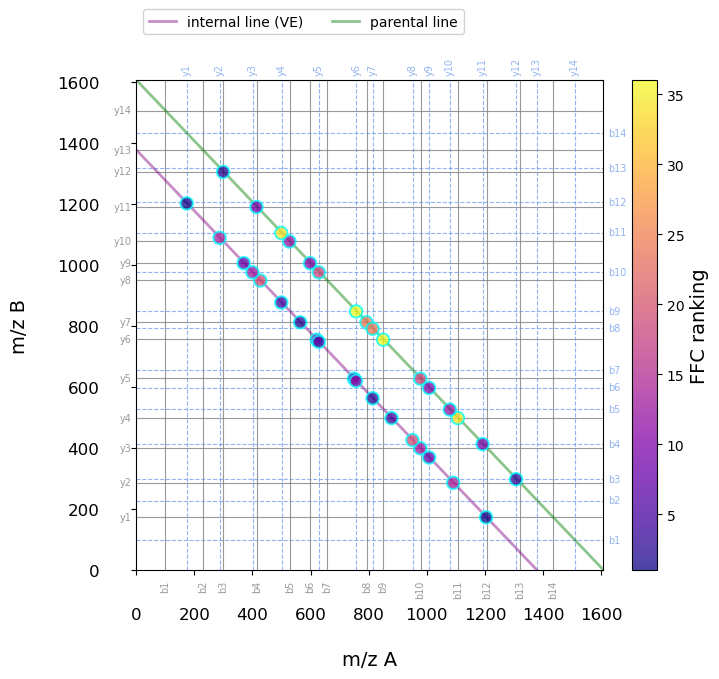

(<Figure size 800x700 with 2 Axes>, <Axes: xlabel='m/z A', ylabel='m/z B'>)

In [866]:
exact_lines = [
    {"slope": -1, "intercept": 1608.869 - 229.112, "color": "purple", "label": "internal line (VE)"},
    {"slope": -1, "intercept": 1608.869, "color": "green", "label": "parental line"},
]



plot_ffc_map_full_grid(
    df_parent_tfcc,
    mz_a_col="tffc_A",
    mz_b_col="tffc_B",
    ranking_col="Ranking",
    lines=exact_lines,
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    grid_alpha=0.8,
    grid_label_alpha=0.8,
    grid_label_fontsize=7,
    
)

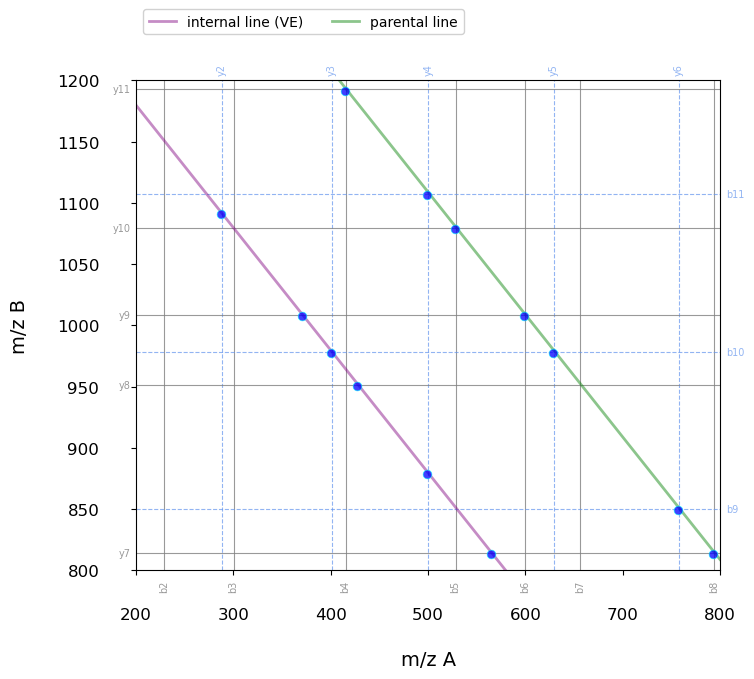

(<Figure size 800x700 with 1 Axes>, <Axes: xlabel='m/z A', ylabel='m/z B'>)

In [867]:
exact_lines = [
    {"slope": -1, "intercept": 1608.869 - 229.112, "color": "purple", "label": "internal line (VE)"},
    {"slope": -1, "intercept": 1608.869, "color": "green", "label": "parental line"},
]



plot_ffc_map_simple(
    df_parent_tfcc,
    mz_a_col="tffc_A",
    mz_b_col="tffc_B",
    lines=exact_lines,
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    grid_alpha=0.8,
    grid_label_alpha=0.8,
    grid_label_fontsize=7,
    xlim = (200,800),
    ylim = (800,1200)
    
)

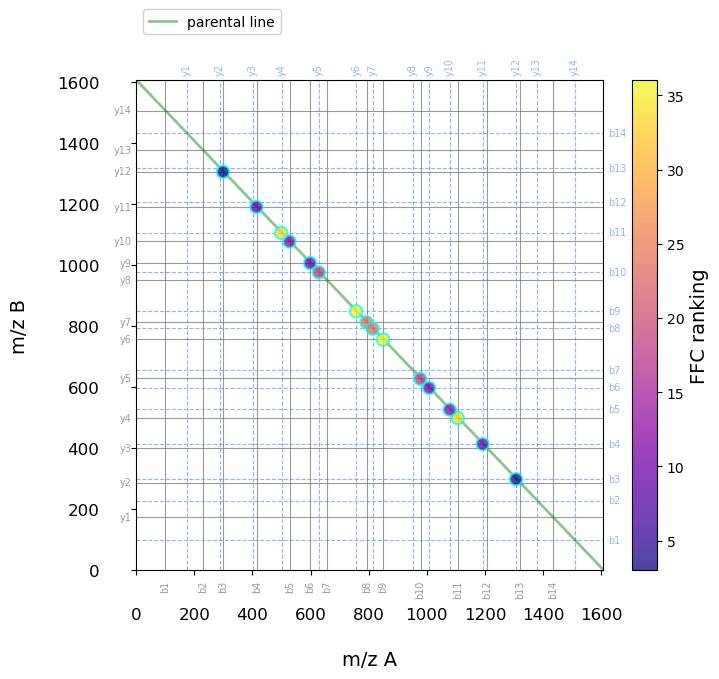

(<Figure size 800x700 with 2 Axes>, <Axes: xlabel='m/z A', ylabel='m/z B'>)

In [868]:
ranking_to_keep = [3, 9, 12, 10, 24, 36, 18, 34, 61] 
df_parent_tfcc = tffc_table_doubled[tffc_table_doubled["Ranking"].isin(ranking_to_keep)].copy()


exact_lines = [
    {"slope": -1, "intercept": 1608.869, "color": "green", "label": "parental line"},
]



plot_ffc_map_full_grid(
    df_parent_tfcc,
    mz_a_col="tffc_A",
    mz_b_col="tffc_B",
    ranking_col="Ranking",
    lines=exact_lines,
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    grid_alpha=0.8,
    grid_label_alpha=0.8,
    grid_label_fontsize=7
)

In [869]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_ffc_map_simple(
    df,
    mz_a_col="mz_A",
    mz_b_col="mz_B",
    lines=None,
    b_ions=None,
    y_ions=None,
    xlim=None,
    ylim=None,
    start_from_zero=True,
    figsize=(8, 7),
    point_size=40,
    point_color="blue",
    point_alpha=0.75,
    point_edgecolor="cyan",
    point_linewidth=0.5,
    line_alpha=0.45,
    grid_alpha=0.12,
    grid_linewidth=0.8,
    grid_label_alpha=0.45,
    grid_label_fontsize=7,
    show_grid_labels=True,
    dashed_grid_color="cornflowerblue",
    dashed_grid_alpha=0.70,
):
    """
    Plot an FFC map with uniform-color dots (no ranking colorbar).

    Full b/y ion grids on all four sides:
      - b-ions: solid vertical lines (labels at bottom)
                dashed horizontal lines (labels at right)
      - y-ions: solid horizontal lines (labels at left)
                dashed vertical lines (labels at top)

    If lines=None, no diagonal/charge lines will be drawn.
    """

    data = df.copy()

    data[mz_a_col] = pd.to_numeric(data[mz_a_col], errors="coerce")
    data[mz_b_col] = pd.to_numeric(data[mz_b_col], errors="coerce")

    data = data.dropna(subset=[mz_a_col, mz_b_col])

    if data.empty:
        raise ValueError("No valid data points remain after cleaning the dataframe.")

    # Determine plot ranges
    if xlim is None:
        if start_from_zero:
            xlim = (0, data[mz_a_col].max() + 300)
        else:
            xlim = (data[mz_a_col].min() - 50, data[mz_a_col].max() + 300)

    if ylim is None:
        if start_from_zero:
            ylim = (0, data[mz_b_col].max() + 300)
        else:
            ylim = (data[mz_b_col].min() - 50, data[mz_b_col].max() + 300)

    fig, ax = plt.subplots(figsize=figsize)

    # ------------------------------------------------------------
    # Label offsets — all labels sit OUTSIDE the plot area
    # ------------------------------------------------------------

    # b-ion solid vertical → labels below x-axis
    bottom_label_y = ylim[0] - 0.02 * (ylim[1] - ylim[0])
    # y-ion solid horizontal → labels left of y-axis
    left_label_x   = xlim[0] - 0.01 * (xlim[1] - xlim[0])
    # y-ion dashed vertical → labels above top edge
    top_label_y    = ylim[1] + 0.01 * (ylim[1] - ylim[0])
    # b-ion dashed horizontal → labels right of right edge
    right_label_x  = xlim[1] + 0.01 * (xlim[1] - xlim[0])

    # ------------------------------------------------------------
    # b-ions: solid vertical (bottom) + dashed horizontal (right)
    # ------------------------------------------------------------

    if b_ions is not None:
        for ion_name, mz_value in b_ions.items():
            mz_value = float(mz_value)

            # Solid vertical line, label below
            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(
                    x=mz_value, color="gray", alpha=grid_alpha,
                    linewidth=grid_linewidth, linestyle="-", zorder=0,
                )
                if show_grid_labels:
                    ax.text(
                        mz_value, bottom_label_y, ion_name,
                        color="gray", alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize, rotation=90,
                        ha="center", va="top", zorder=1,
                        clip_on=False,
                    )

            # Dashed horizontal line, label at right outside
            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(
                    y=mz_value, color=dashed_grid_color, alpha=dashed_grid_alpha,
                    linewidth=grid_linewidth, linestyle="--", zorder=0,
                )
                if show_grid_labels:
                    ax.text(
                        right_label_x, mz_value, ion_name,
                        color=dashed_grid_color, alpha=dashed_grid_alpha,
                        fontsize=grid_label_fontsize,
                        ha="left", va="center", zorder=1,
                        clip_on=False,
                    )

    # ------------------------------------------------------------
    # y-ions: solid horizontal (left) + dashed vertical (top)
    # ------------------------------------------------------------

    if y_ions is not None:
        for ion_name, mz_value in y_ions.items():
            mz_value = float(mz_value)

            # Solid horizontal line, label at left outside
            if ylim[0] <= mz_value <= ylim[1]:
                ax.axhline(
                    y=mz_value, color="gray", alpha=grid_alpha,
                    linewidth=grid_linewidth, linestyle="-", zorder=0,
                )
                if show_grid_labels:
                    ax.text(
                        left_label_x, mz_value, ion_name,
                        color="gray", alpha=grid_label_alpha,
                        fontsize=grid_label_fontsize,
                        ha="right", va="center", zorder=1,
                        clip_on=False,
                    )

            # Dashed vertical line, label at top outside
            if xlim[0] <= mz_value <= xlim[1]:
                ax.axvline(
                    x=mz_value, color=dashed_grid_color, alpha=dashed_grid_alpha,
                    linewidth=grid_linewidth, linestyle="--", zorder=0,
                )
                if show_grid_labels:
                    ax.text(
                        mz_value, top_label_y, ion_name,
                        color=dashed_grid_color, alpha=dashed_grid_alpha,
                        fontsize=grid_label_fontsize, rotation=90,
                        ha="center", va="bottom", zorder=1,
                        clip_on=False,
                    )

    # ------------------------------------------------------------
    # Scatter plot — uniform color, smaller dots
    # ------------------------------------------------------------

    ax.scatter(
        data[mz_a_col],
        data[mz_b_col],
        s=point_size,
        c=point_color,
        edgecolors=point_edgecolor,
        linewidths=point_linewidth,
        alpha=point_alpha,
        zorder=3,
    )

    # ------------------------------------------------------------
    # Draw main diagonal/charge lines only if provided
    # ------------------------------------------------------------

    if lines is not None:
        x_values = np.linspace(xlim[0], xlim[1], 500)

        for line in lines:
            slope = line.get("slope")
            intercept = line.get("intercept")
            color = line.get("color", "black")
            label = line.get("label", None)

            y_values = slope * x_values + intercept

            ax.plot(
                x_values,
                y_values,
                color=color,
                alpha=line_alpha,
                linewidth=2,
                label=label,
                zorder=2,
            )

        if any(line.get("label") is not None for line in lines):
            ax.legend(
                loc="lower left",
                bbox_to_anchor=(0.0, 1.08),
                fontsize=10,
                framealpha=0.9,
                ncol=2,
            )

    # ------------------------------------------------------------
    # Axis labels and formatting
    # ------------------------------------------------------------

    ax.set_xlabel("m/z A", fontsize=14, labelpad=20)
    ax.set_ylabel("m/z B", fontsize=14, labelpad=20)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.tick_params(axis="x", labelsize=12, pad=23)
    ax.tick_params(axis="y", labelsize=12, pad=23)

    plt.tight_layout()
    plt.subplots_adjust(left=0.15, right=0.88, top=0.85, bottom=0.15)
    plt.show()

    return fig, ax

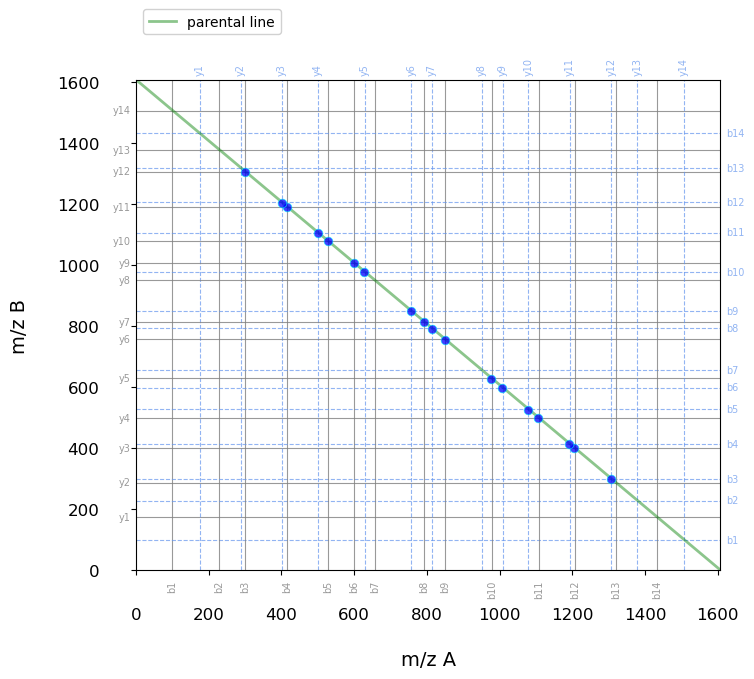

(<Figure size 800x700 with 1 Axes>, <Axes: xlabel='m/z A', ylabel='m/z B'>)

In [870]:
ranking_to_keep = [3, 9, 12, 10, 24, 36, 18, 34, 61, 27] 
df_parent_tfcc = tffc_table_doubled[tffc_table_doubled["Ranking"].isin(ranking_to_keep)].copy()


exact_lines = [
    {"slope": -1, "intercept": 1608.869, "color": "green", "label": "parental line"},
]



plot_ffc_map_simple(
    df_parent_tfcc,
    mz_a_col="tffc_A",
    mz_b_col="tffc_B",
    lines=exact_lines,
    b_ions=b_ions,
    y_ions=y_ions,
    start_from_zero=True,
    grid_alpha=0.8,
    grid_label_alpha=0.8,
    grid_label_fontsize=7
)

In [871]:
df_parent_tfcc

,Ranking,m/z A,Interpretation A,error A,m/z B,Interpretation B,error B,charge A,charge B,tffc_A,tffc_B
2,3,300.156,b3 (+1),-0.001,654.359,y12 (+2),-0.002,1.0,2.0,299.1488,1306.7036
8,9,415.184,b4 (+1),-0.002,596.846,y11 (+2),-0.002,1.0,2.0,414.1768,1191.6776
9,10,599.306,b6 (+1),-0.002,504.785,y9 (+2),-0.002,1.0,2.0,598.2988,1007.5556
11,12,528.269,b5 (+1),-0.002,540.303,y10 (+2),-0.002,1.0,2.0,527.2618,1078.5916
17,18,489.737,b10 (+2),-0.002,629.401,y5 (+1),-0.003,2.0,1.0,977.4596,628.3938
23,24,397.197,b8 (+2),-0.001,814.482,y7 (+1),-0.004,2.0,1.0,792.3796,813.4748
26,27,603.793,b12 (+2),-0.002,401.289,y3 (+1) (C13),-0.002,2.0,1.0,1205.5716,400.2818
33,34,554.259,b11 (+2),-0.002,500.357,y4 (+1),-0.002,2.0,1.0,1106.5036,499.3498
35,36,425.708,b9 (+2),-0.001,757.460,y6 (+1),-0.003,2.0,1.0,849.4016,756.4528
52,3,654.359,y12 (+2),-0.002,300.156,b3 (+1),-0.001,2.0,1.0,1306.7036,299.1488
